# WRM Module 2 — Timeseries Analysis
**Ill River & Rhein River: Discharge and Suspended Sediment Concentration**

Stations:
- **Gisingen** (Ill River, Austria): Q 1976–2013 (15 min), C 2003–2021 (15 min)
- **Diepoldsau, Rietbrücke** (Rhein River, CH): Q 1984–2025 (10 min), C 2012–2025 (10 min)

In [1]:
# Global imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA = "../DATA/"
FILES = {
    "gis_Q": (DATA + "Q_Gisingen_1976-2023.csv",   "q_m3s"),
    "gis_C": (DATA + "SSC_Gisingen_2003-2020.csv",  "ssc_gL"),
    "die_Q": (DATA + "Q_Diepoldsau_m3s.csv",         "q_m3s"),
    "die_C": (DATA + "SSC_Diepoldsau_gL.csv",         "ssc_gL"),
}
LABELS = {
    "gis_Q": "Gisingen Q (m3/s)",
    "gis_C": "Gisingen C (g/L)",
    "die_Q": "Diepoldsau Q (m3/s)",
    "die_C": "Diepoldsau C (g/L)",
}

---
## Section 1 — Timeseries Review

**Objectives:**
1. Resample all sub-hourly series to monthly means.
2. Plot Q and C for both stations over their full record length.
3. Test for a linear trend via OLS regression (H₀: slope = 0, α = 5%).
4. Remove the mean (or significant trend) to obtain a zero-mean series z(t) with variance σ²_z.
5. Discuss whether this is sufficient for stationarity and interpret any trends physically.


In [2]:
# Section 1 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath("."))
from helpers import load_monthly, fit_linear_trend, detrend_series, summarise_trend

In [3]:
# Section 1 — MAIN

# 1. Load and resample to monthly means
gis_Q_monthly = load_monthly(*FILES["gis_Q"])
gis_C_monthly = load_monthly(*FILES["gis_C"])
die_Q_monthly = load_monthly(*FILES["die_Q"])
die_C_monthly = load_monthly(*FILES["die_C"])

monthly_series = {
    "Gisingen Q (m3/s)":   gis_Q_monthly,
    "Gisingen C (g/L)":    gis_C_monthly,
    "Diepoldsau Q (m3/s)": die_Q_monthly,
    "Diepoldsau C (g/L)":  die_C_monthly,
}

# 2. Fit linear trend and test significance at alpha = 5%
trends = {label: fit_linear_trend(s) for label, s in monthly_series.items()}

# 3. Detrend to zero-mean series z(t)
detrended   = {}
variances   = {}
trend_flags = {}
for label, s in monthly_series.items():
    z, sigma2, removed = detrend_series(s, trends[label], alpha=0.05)
    detrended[label]   = z
    variances[label]   = sigma2
    trend_flags[label] = removed

# 4. Seasonal variance: std per calendar month on detrended series
# A stationary series should have roughly equal std across all 12 months.
# A large spread in monthly std indicates residual non-stationarity.
seasonal_std = {}
for label in monthly_series:
    z = detrended[label].dropna()
    df_tmp = z.to_frame('val')
    df_tmp['month'] = df_tmp.index.month
    seasonal_std[label] = df_tmp.groupby('month')['val'].std()


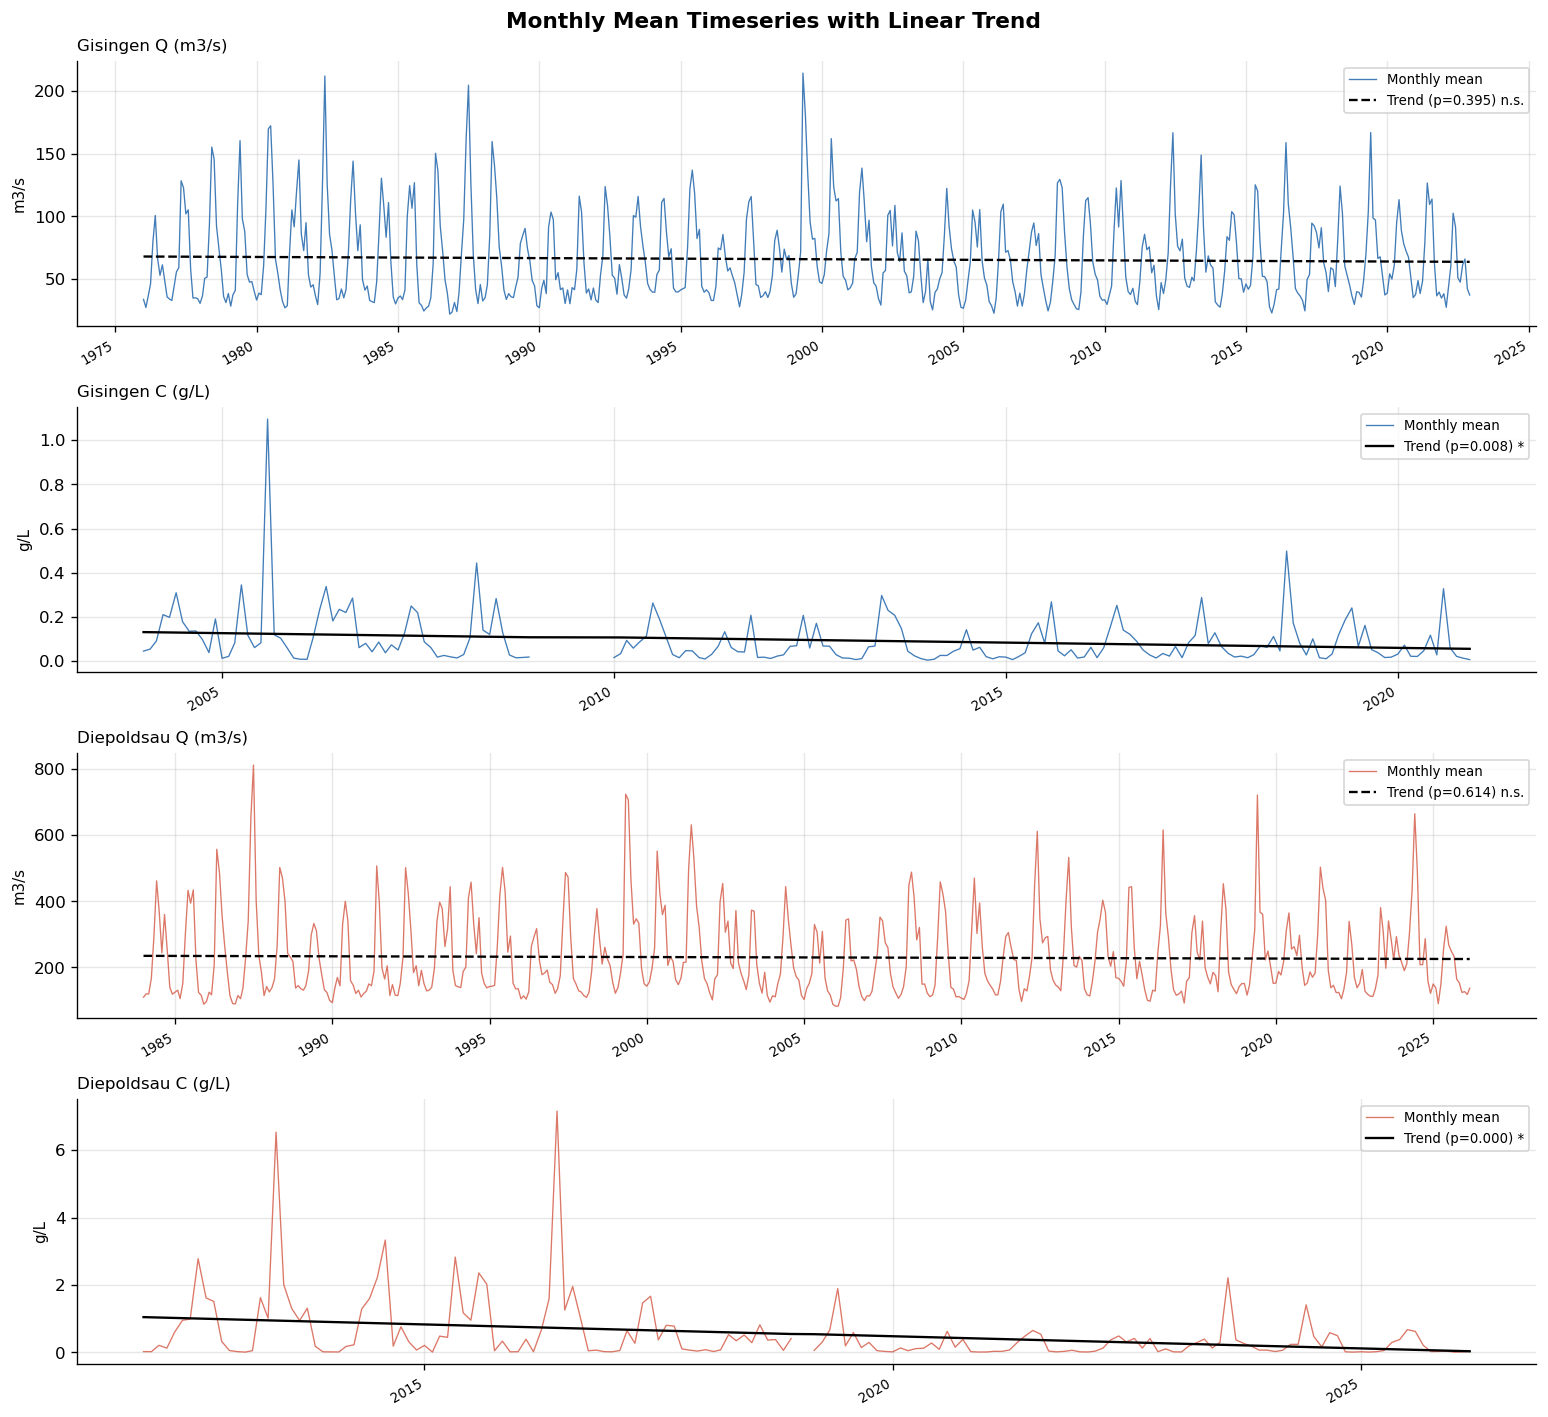

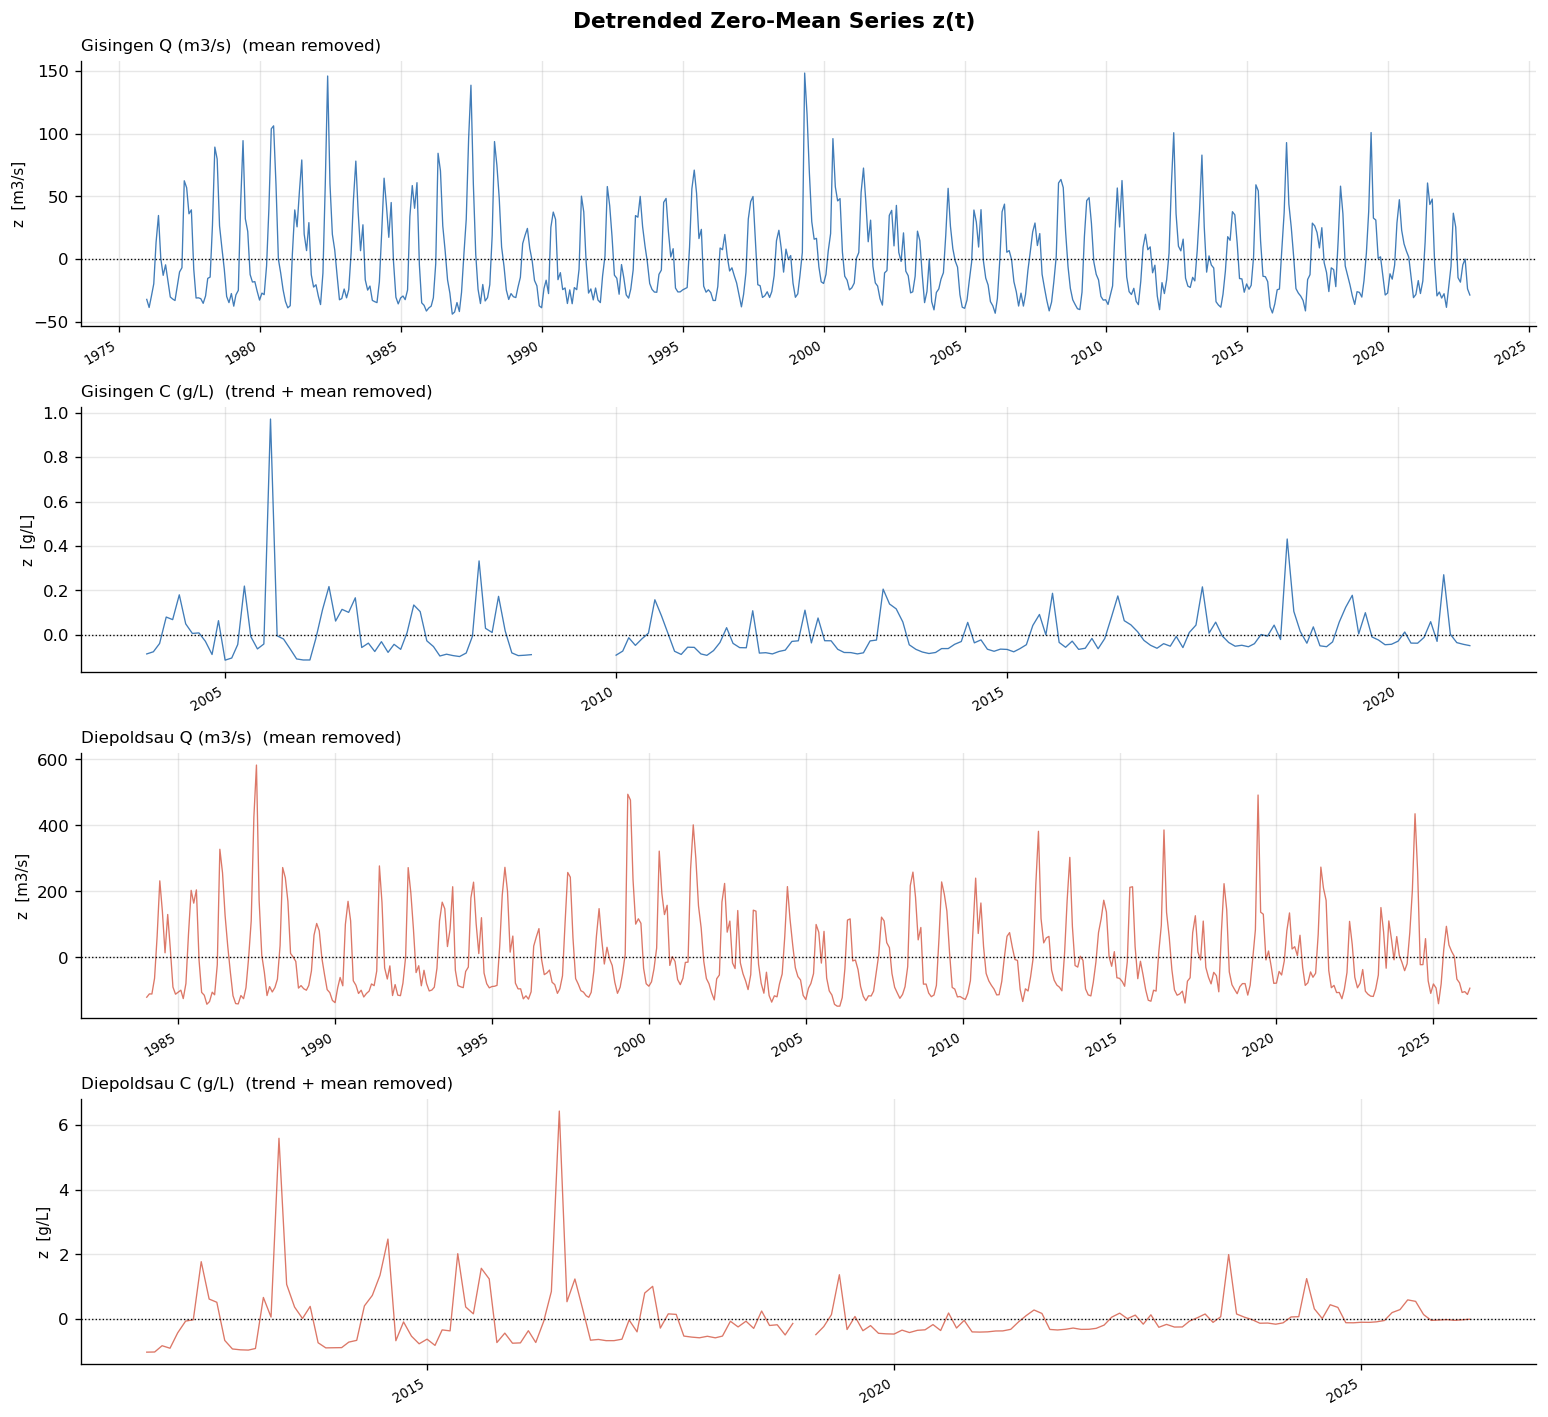

In [4]:
# Section 1 — PLOT

COLORS   = {"Gisingen": "#2166ac", "Diepoldsau": "#d6604d"}
labels_s1 = list(monthly_series.keys())
series_s1 = list(monthly_series.values())
units_s1  = ["m3/s", "g/L", "m3/s", "g/L"]
stations_s1 = ["Gisingen", "Gisingen", "Diepoldsau", "Diepoldsau"]

# Figure 1: Raw monthly timeseries with trend line
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=False)
fig.suptitle("Monthly Mean Timeseries with Linear Trend", fontsize=13, fontweight="bold")

for ax, label, s, unit, station in zip(axes, labels_s1, series_s1, units_s1, stations_s1):
    color = COLORS[station]
    ax.plot(s.index, s.values, color=color, linewidth=0.8, alpha=0.85, label="Monthly mean")
    tr = trends[label]
    p  = tr["p_value"]
    ls = "-" if p < 0.05 else "--"
    sig_marker = " *" if p < 0.05 else " n.s."
    lbl = f"Trend (p={p:.3f}){sig_marker}"
    ax.plot(tr["fitted"].index, tr["fitted"].values, color="k", linewidth=1.4, linestyle=ls, label=lbl)
    ax.set_ylabel(unit, fontsize=9)
    ax.set_title(label, fontsize=10, loc="left")
    ax.legend(fontsize=8, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("../DATA/fig1_raw_timeseries.png", bbox_inches="tight")
plt.show()

# Figure 2: Detrended zero-mean series
fig2, axes2 = plt.subplots(4, 1, figsize=(13, 12), sharex=False)
fig2.suptitle("Detrended Zero-Mean Series z(t)", fontsize=13, fontweight="bold")

for ax, label, unit, station in zip(axes2, labels_s1, units_s1, stations_s1):
    color = COLORS[station]
    z     = detrended[label]
    tag   = "(trend + mean removed)" if trend_flags[label] else "(mean removed)"
    ax.plot(z.index, z.values, color=color, linewidth=0.8, alpha=0.85)
    ax.axhline(0, color="k", linewidth=0.8, linestyle=":")
    ax.set_title(f"{label}  {tag}", fontsize=10, loc="left")
    ax.set_ylabel(f"z  [{unit}]", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("../DATA/fig2_detrended_series.png", bbox_inches="tight")
plt.show()

In [5]:
# Section 1 — PRINT

rows = [summarise_trend(label, trends[label], alpha=0.05) for label in labels_s1]
df_trend = pd.DataFrame(rows).set_index("Series")
print("=== Linear Trend Test Results (alpha = 5%) ===\n")
print(df_trend.to_string())

print("\n=== Zero-Mean Series: Sample Variance sigma^2_z ===\n")
for label in labels_s1:
    unit = "m3/s" if "Q" in label else "g/L"
    print(f"  {label:<25s}  sigma2_z = {variances[label]:>12.4f}  [{unit}^2]")

print("\n=== Seasonal Std per Calendar Month (detrended series) ===\n")
print("  Ratio max/min std > 2 indicates significant residual seasonal variance.\n")
for label in labels_s1:
    s_std = seasonal_std[label]
    ratio = s_std.max() / s_std.min()
    unit  = "m3/s" if "Q" in label else "g/L"
    print(f"  {label:<25s}  std range [{s_std.min():.3f}, {s_std.max():.3f}] {unit}  max/min ratio = {ratio:.2f}")

print("\n=== Monthly Data Record Lengths ===\n")
for label, s in monthly_series.items():
    valid    = s.dropna()
    total    = len(s)
    n_valid  = len(valid)
    coverage = 100 * n_valid / total if total > 0 else 0
    print(f"  {label:<25s}  {valid.index[0].date()} to {valid.index[-1].date()}"
          f"  |  {n_valid}/{total} months valid ({coverage:.1f}%)")

=== Linear Trend Test Results (alpha = 5%) ===

                    Slope (units/month) p-value      R² Significant (5%)
Series                                                                  
Gisingen Q (m3/s)           -7.5179e-03  0.3952  0.0013               no
Gisingen C (g/L)            -3.9611e-04  0.0076  0.0369              YES
Diepoldsau Q (m3/s)         -1.9002e-02  0.6136  0.0005               no
Diepoldsau C (g/L)          -6.0277e-03  0.0000  0.0985              YES

=== Zero-Mean Series: Sample Variance sigma^2_z ===

  Gisingen Q (m3/s)          sigma2_z =    1166.3124  [m3/s^2]
  Gisingen C (g/L)           sigma2_z =       0.0127  [g/L^2]
  Diepoldsau Q (m3/s)        sigma2_z =   15335.4259  [m3/s^2]
  Diepoldsau C (g/L)         sigma2_z =       0.7961  [g/L^2]

=== Seasonal Std per Calendar Month (detrended series) ===

  Ratio max/min std > 2 indicates significant residual seasonal variance.

  Gisingen Q (m3/s)          std range [7.130, 30.102] m3/s  max/min ratio

### Section 1 — Discussion

#### Visual Inspection

All four timeseries exhibit a strong **seasonal oscillation** with a 12-month period,
as expected for monthly hydrological data. Peak discharge and sediment concentrations
occur in late spring / early summer (snowmelt and convective storms), with minima in
winter. This periodic behaviour means the raw series are **not strictly stationary** —
the mean and variance both vary with the calendar month.

Beyond seasonality, the long-term mean of the Q series appears visually stable over
the full record. The C series, however, show a visible downward drift over time,
particularly at Diepoldsau.

---

#### Linear Trend Test (α = 5 %)

| Series | Slope (units/month) | p-value | Significant? |
|---|---|---|---|
| Gisingen Q (m³/s)   | −7.52 × 10⁻³ | 0.395  | no          |
| Gisingen C (g/L)    | −3.96 × 10⁻⁴ | 0.008  | **YES**     |
| Diepoldsau Q (m³/s) | −1.90 × 10⁻² | 0.614  | no          |
| Diepoldsau C (g/L)  | −6.03 × 10⁻³ | <0.001 | **YES**     |

Neither discharge series has a significant linear trend. Both suspended sediment
concentration series show a significant **negative trend** — concentrations have
declined over the observation period at both stations.

---

#### Detrending and Normalisation

For **Gisingen Q** and **Diepoldsau Q** only the sample mean was subtracted.
For **Gisingen C** and **Diepoldsau C** the fitted linear trend was removed first,
then the mean, yielding zero-mean series with variances:

| Series | σ²_z |
|---|---|
| Gisingen Q   | 1 166.31 (m³/s)² |
| Gisingen C   | 0.0127 (g/L)²    |
| Diepoldsau Q | 15 335.43 (m³/s)² |
| Diepoldsau C | 0.7961 (g/L)²    |

Note: the trend test above is performed on the **original-scale series** as an
exploratory analysis. From Section 2 onwards all series are **log-transformed**
before detrending, so the linear trend is removed in log-space (equivalent to
removing an exponential trend in original space). 
---

#### Seasonality

All four series exhibit a pronounced 12-month seasonal cycle. The standard deviation
varies considerably across calendar months (max/min ratio > 2 for the Q series),
meaning the series remain **non-stationary after detrending alone**. To achieve weak
stationarity before fitting AR/ARMA models, the following pipeline is applied in Section 2:

1. **Log-transform** the raw series: y(t) = log(x(t)) — compresses the right skew,
   stabilises variance, and brings the distribution closer to normal.
2. **Detrend** in log-space — removes any linear trend in log(x), equivalent to an
   exponential trend in original space.
3. **Subtract** the monthly climatological mean in log-space — removes the seasonal mean.
4. **Divide** by the monthly climatological standard deviation (Q series only) —
   removes residual seasonal heteroscedasticity.

The result is a dimensionless standardised anomaly z*(t) with approximately zero mean
and unit variance for every calendar month.

---

#### Physical Interpretation of Trends

**Discharge (Q):** No significant trend at either station. Minor fluctuations are attributed to natural multi-decadal climate variability.

**Sediment concentration (C):** The significant negative trend at both stations is a
**physical signal**, consistent with the well-documented decline in suspended sediment
loads in regulated Alpine rivers. Contributing factors include:

- **Reservoir trapping** by the Illspitz Kraftwerk and upstream impoundments intercepting
  suspended material before it reaches the gauging stations.
- **Improved land management** — reforestation and erosion-control measures reducing
  hillslope sediment supply.
- **Reduced flood frequency or magnitude** decreasing the mobilisation of fine sediment.


---
## Section 2 — Timeseries Modelling

**Objectives:**
1. **Log-transform** all series, detrend in log-space, then apply **monthly standardisation** (subtract log-space climatological mean; divide by log-space std for Q series) to yield a dimensionless anomaly z*(t) [–].
2. Compute empirical ACF and PACF with 95% CI. Use segment-averaged ACF/PACF for gapped series.
3. Fit AR(p) and ARMA(p,q) models for each series.
4. Discuss model order selection based on ACF / PACF shape.


In [6]:
# Section 2 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath("."))
from helpers import (
    load_monthly, fit_linear_trend, detrend_series,
    remove_seasonal_means,
    compute_acf_with_ci, compute_pacf_with_ci, compute_acf_segmented,
    fit_ar, fit_arma, aic_grid_search,
)


In [7]:
# Section 2 — MAIN

# --- Step 1: reload monthly data, detrend, remove seasonal means ---
# (Section 2 is self-contained — data is reloaded independently of Section 1)
anomalies = {}
clims     = {}
detrended = {}
for key, (fp, col) in FILES.items():
    monthly        = load_monthly(fp, col)
    monthly_log    = np.log(monthly.clip(lower=1e-9))   # log-transform before detrending
    trend          = fit_linear_trend(monthly_log)
    z, _, _        = detrend_series(monthly_log, trend)
    anom, clim, _  = remove_seasonal_means(z, standardise=(key not in ('gis_C', 'die_C')))
    anomalies[key] = anom
    clims[key]     = clim
    detrended[key] = z

# --- Step 2: ACF and PACF ---
# Gisingen C : gaps in 2009 and 2021 -> segmented (2 segments)
# Diepoldsau C: gap in 2019          -> segmented (2 segments)
# Q series   : no significant gaps   -> standard
MAX_LAGS = 36

acf_results  = {}
pacf_results = {}
for key in FILES:
    s = anomalies[key]
    if key in ('gis_C', 'die_C'):
        lags, acf_avg, pacf_avg, ci, _ = compute_acf_segmented(s, max_lags=MAX_LAGS)
        acf_results[key]  = (lags, acf_avg,  ci)
        pacf_results[key] = (lags, pacf_avg, ci)
    else:
        lags_a, acf_v, ci_a  = compute_acf_with_ci(s,  max_lags=MAX_LAGS)
        lags_p, pacf_v, ci_p = compute_pacf_with_ci(s, max_lags=MAX_LAGS)
        acf_results[key]  = (lags_a, acf_v,  ci_a)
        pacf_results[key] = (lags_p, pacf_v, ci_p)

# --- Step 3: Choose AR and ARMA orders from ACF / PACF inspection ---
#
# All Q series: PACF cuts off after lag 1     -> AR(1),   ARMA(1,1)
# All C series: ACF/PACF show weak but present structure -> AR(1),   ARMA(1,1)
#
# Orders determined by AIC/BIC grid search (see model selection cell below)
# gis_Q: AR(1) BIC-optimal; ARMA(1,1) parsimonious ARMA
# gis_C: AR(1) BIC-best, AIC tied with ARMA(2,2); short record (n=192)
# die_Q: AR(3) AIC-best AR, BIC within 1 of ARMA(1,1); PACF significant at lags 1-3
# die_C: AR(1) BIC-best AR; ARMA(2,2) justified by 5.25 AIC improvement
# Orders re-validated after log transform (see model selection cell)
# gis_Q: AR(1) BIC-optimal; ARMA(1,1) parsimonious
# gis_C: AR(1) BIC-best AR; ARMA(2,2) wins by 13 AIC units — log transform reveals MA structure
# die_Q: AR(3) AIC+BIC-best; ARMA(1,1) parsimonious ARMA
# die_C: AR(1) BIC-optimal; ARMA(1,1) best ARMA (ARMA(2,2) no longer justified after log)
AR_ORDERS   = {'gis_Q': 1, 'gis_C': 1, 'die_Q': 3, 'die_C': 1}
ARMA_ORDERS = {'gis_Q': (1,1), 'gis_C': (2,2), 'die_Q': (1,1), 'die_C': (1,1)}

# --- Step 4: Fit AR and ARMA models ---
ar_models   = {key: fit_ar(anomalies[key], AR_ORDERS[key])      for key in FILES}
arma_models = {key: fit_arma(anomalies[key], *ARMA_ORDERS[key]) for key in FILES}


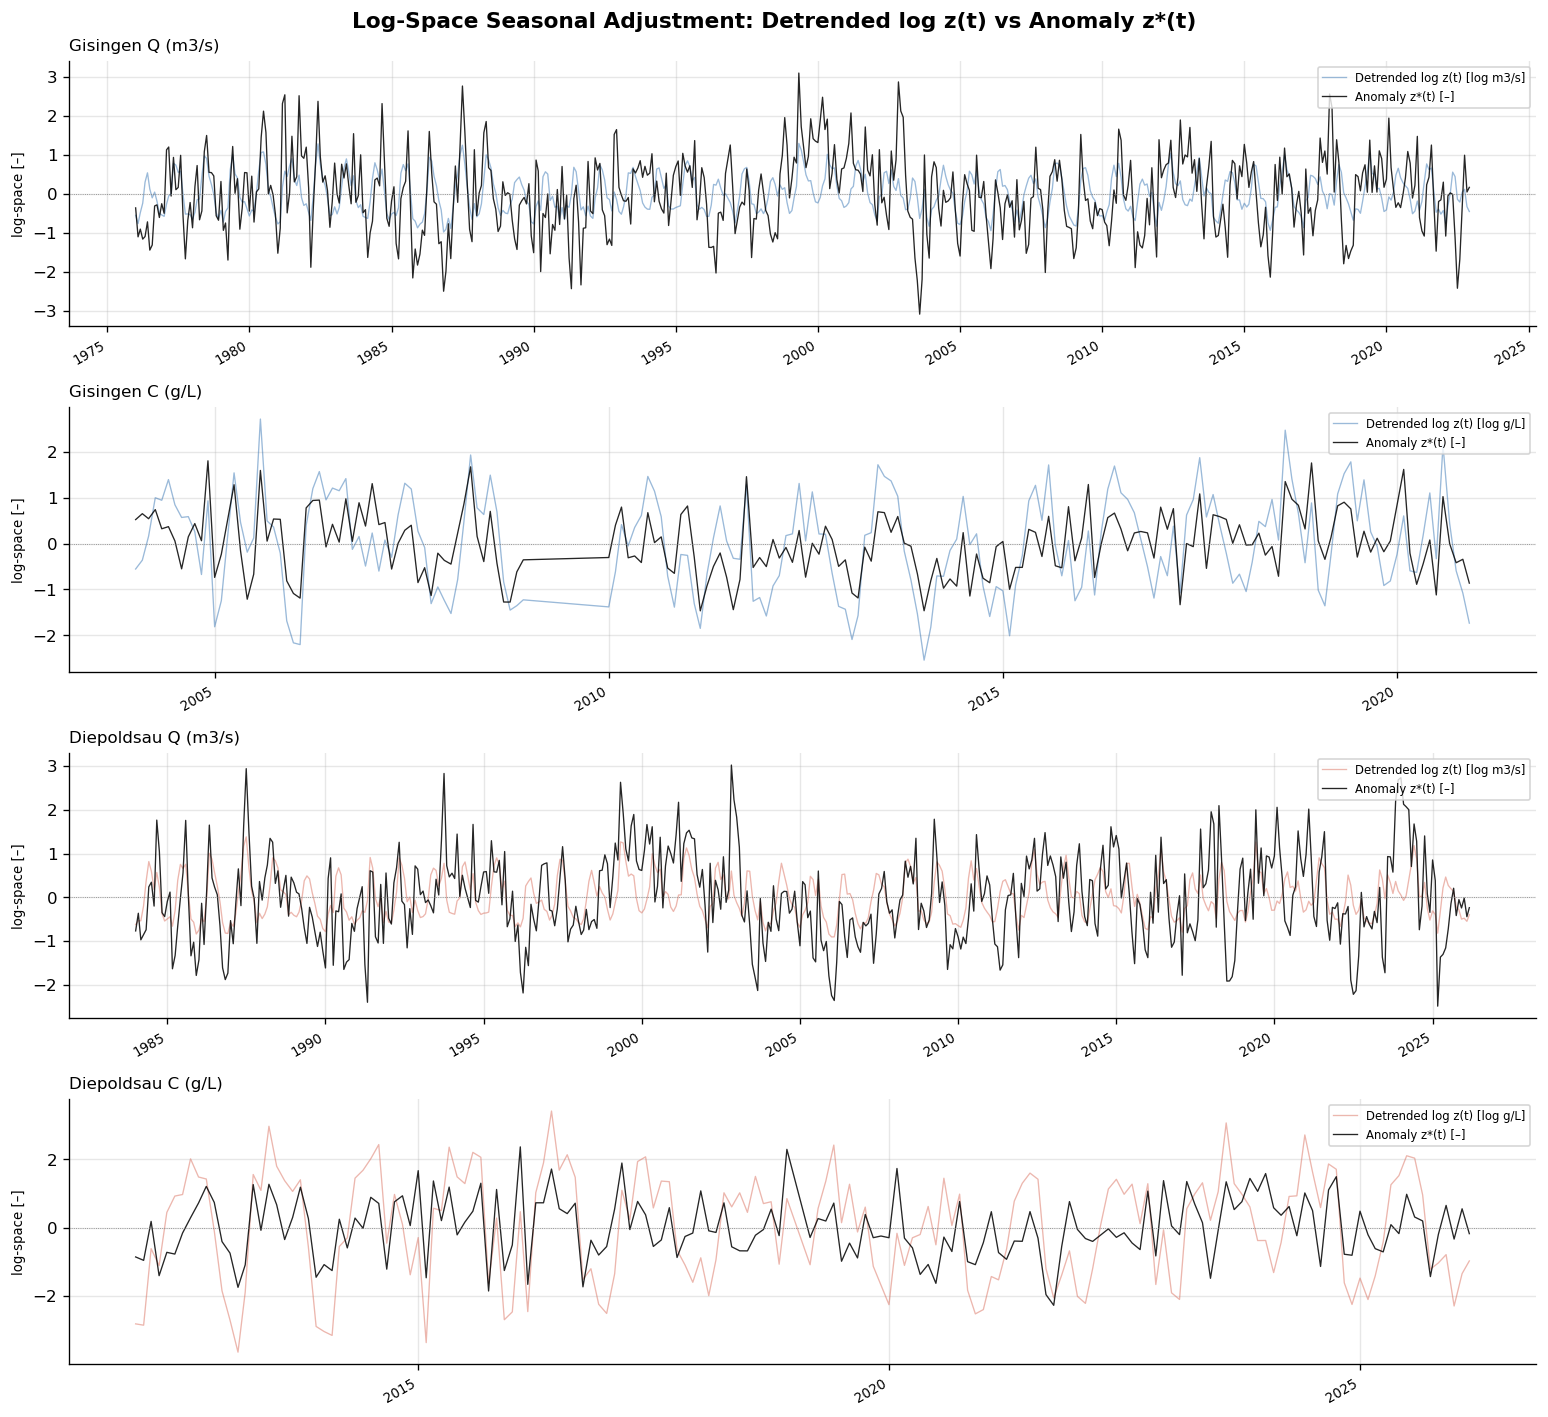

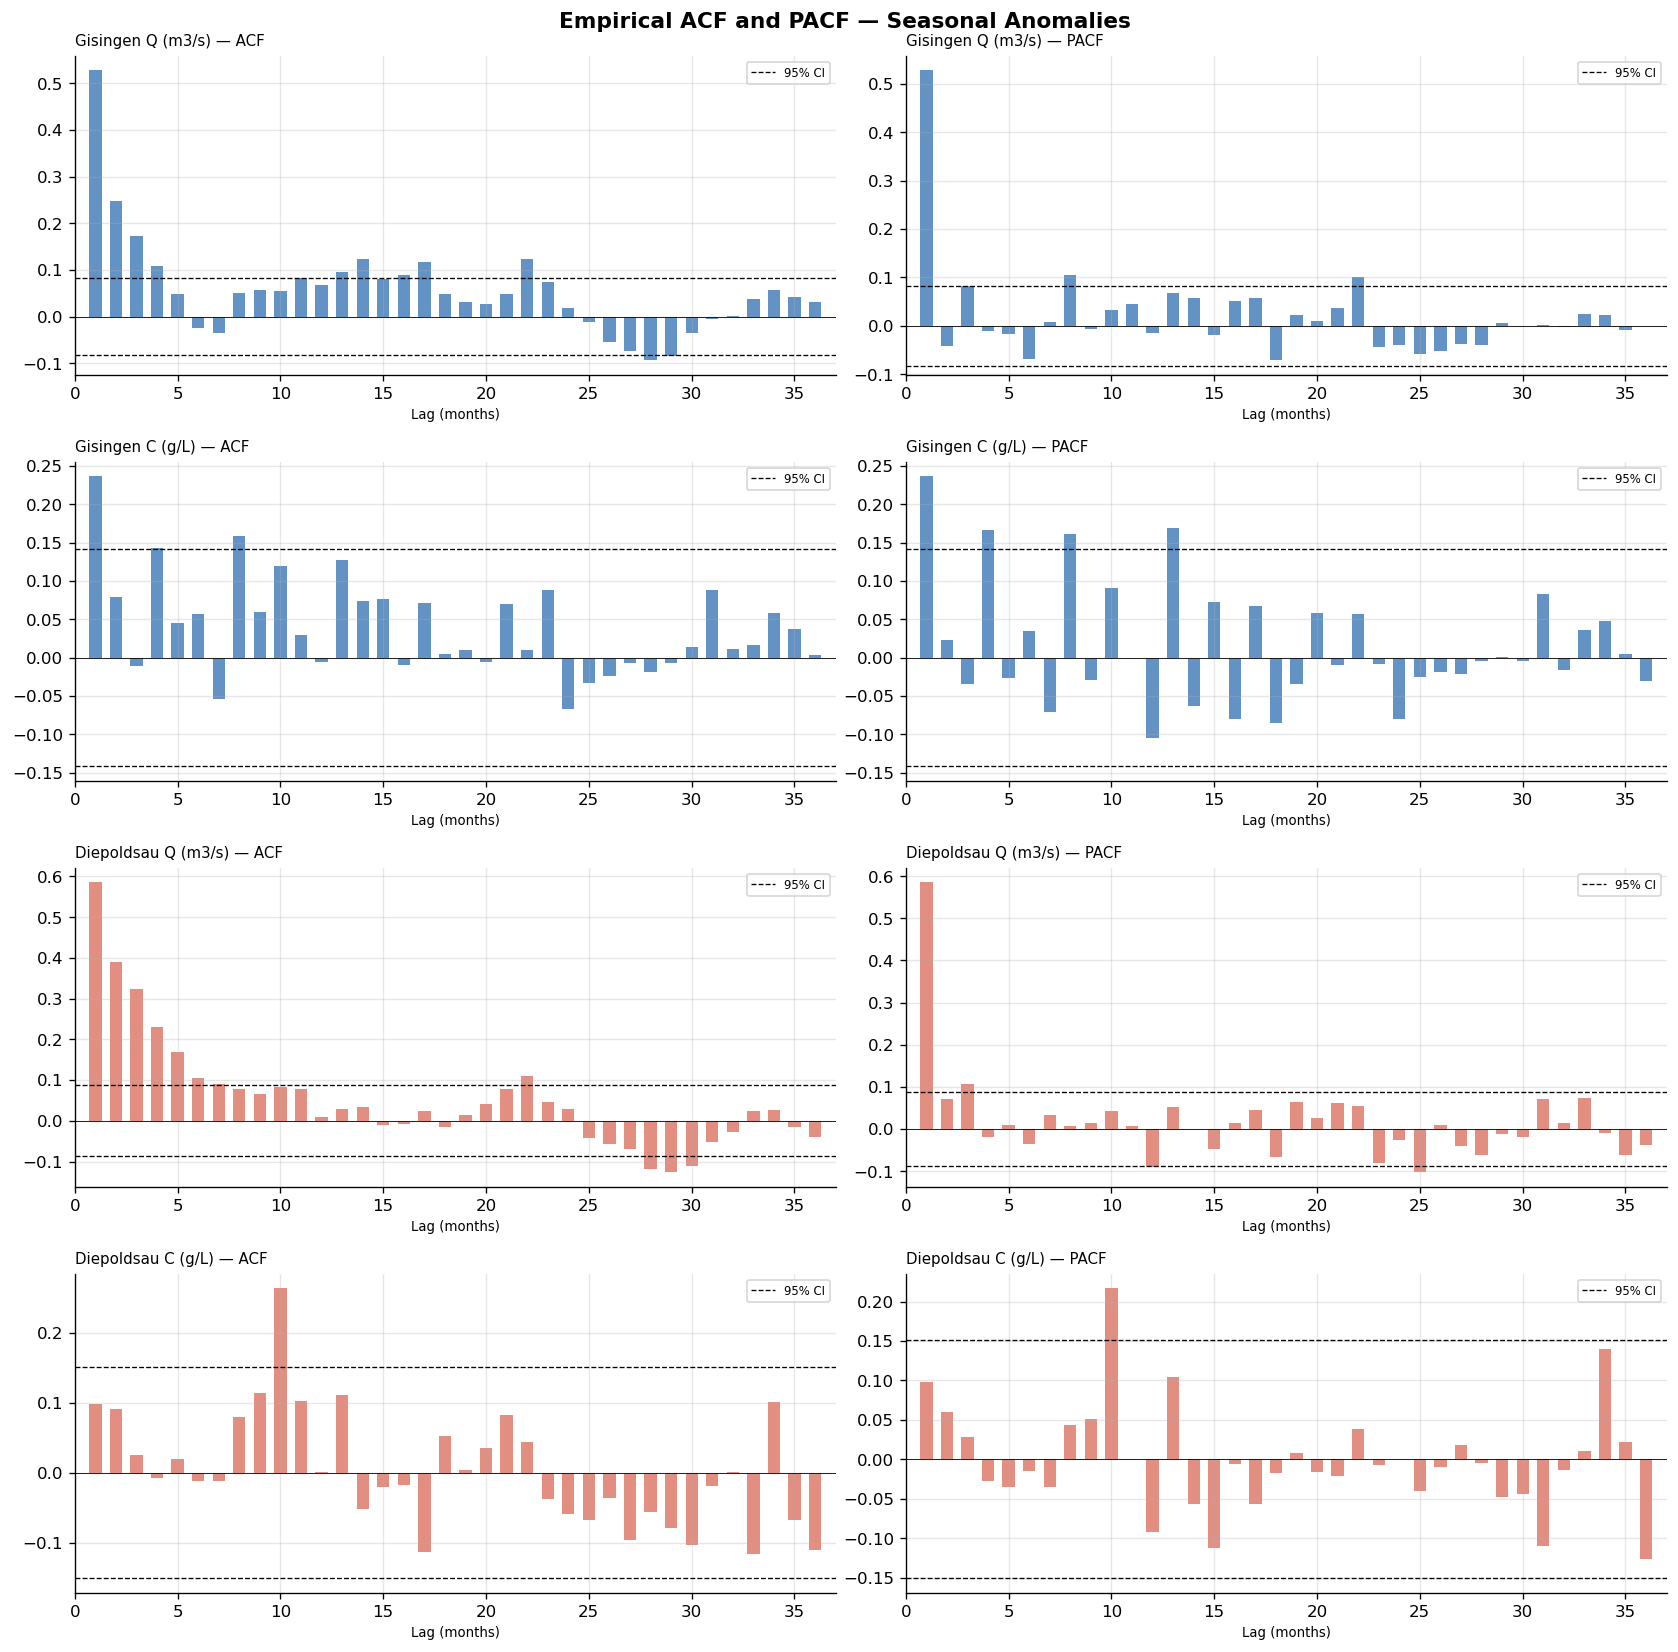

In [8]:
# Section 2 — PLOT

KEYS_S2     = list(FILES.keys())
STATIONS_S2 = ["Gisingen", "Gisingen", "Diepoldsau", "Diepoldsau"]
COLORS_S2   = {"Gisingen": "#2166ac", "Diepoldsau": "#d6604d"}
units_s2    = ["m3/s", "g/L", "m3/s", "g/L"]

# ── Figure 1: Detrended vs Seasonally Adjusted ──────────────────────────
fig0, axes0 = plt.subplots(4, 1, figsize=(13, 12), sharex=False)
fig0.suptitle("Log-Space Seasonal Adjustment: Detrended log z(t) vs Anomaly z*(t)",
               fontsize=13, fontweight="bold")

for ax, key, station, unit in zip(axes0, KEYS_S2, STATIONS_S2, units_s2):
    color  = COLORS_S2[station]
    z_det  = detrended[key].dropna()
    z_anom = anomalies[key].dropna()

    ax.plot(z_det.index,  z_det.values,  color=color, linewidth=0.8,
            alpha=0.45, label=f"Detrended log z(t) [log {unit}]")
    ax.plot(z_anom.index, z_anom.values, color="k",   linewidth=0.8,
            alpha=0.85, label=f"Anomaly z*(t) [–]")
    ax.axhline(0, color="grey", linewidth=0.5, linestyle=":")

    ax.set_title(LABELS[key], fontsize=10, loc="left")
    ax.set_ylabel("log-space [–]", fontsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("../DATA/fig3_seasonal_adjustment.png", bbox_inches="tight")
plt.show()

# ── Figure 2: ACF and PACF ───────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle("Empirical ACF and PACF — Seasonal Anomalies",
              fontsize=13, fontweight="bold")

for row, (key, station) in enumerate(zip(KEYS_S2, STATIONS_S2)):
    color = COLORS_S2[station]
    ax_acf  = axes[row, 0]
    lags_a, acf_v, ci_a = acf_results[key]
    ax_acf.bar(lags_a[1:], acf_v[1:], color=color, alpha=0.7, width=0.6)
    ax_acf.axhline( ci_a, color="k", linestyle="--", linewidth=0.8, label="95% CI")
    ax_acf.axhline(-ci_a, color="k", linestyle="--", linewidth=0.8)
    ax_acf.axhline(0,     color="k", linewidth=0.5)
    ax_acf.set_title(f"{LABELS[key]} — ACF", fontsize=9, loc="left")
    ax_acf.set_xlabel("Lag (months)", fontsize=8)
    ax_acf.set_xlim(0, MAX_LAGS + 1)
    ax_acf.legend(fontsize=7)

    ax_pacf = axes[row, 1]
    lags_p, pacf_v, ci_p = pacf_results[key]
    ax_pacf.bar(lags_p[1:], pacf_v[1:], color=color, alpha=0.7, width=0.6)
    ax_pacf.axhline( ci_p, color="k", linestyle="--", linewidth=0.8, label="95% CI")
    ax_pacf.axhline(-ci_p, color="k", linestyle="--", linewidth=0.8)
    ax_pacf.axhline(0,     color="k", linewidth=0.5)
    ax_pacf.set_title(f"{LABELS[key]} — PACF", fontsize=9, loc="left")
    ax_pacf.set_xlabel("Lag (months)", fontsize=8)
    ax_pacf.set_xlim(0, MAX_LAGS + 1)
    ax_pacf.legend(fontsize=7)

plt.tight_layout()
plt.savefig("../DATA/fig4_acf_pacf.png", bbox_inches="tight")
plt.show()


In [9]:
# Section 2 — MODEL ORDER SELECTION
# AIC/BIC grid search over AR(p) and ARMA(p,q) to justify chosen orders.
# Rule: prefer the simplest model with the lowest AIC; if AIC is tied, choose the one with the lowest BIC.
# global minimum (standard threshold); BIC is used as tiebreaker.

MAX_P, MAX_Q = 6, 3

print('=== AIC / BIC Grid Search — AR(p) and ARMA(p,q) ===\n')
for key in FILES:
    df_grid = aic_grid_search(anomalies[key], max_p=MAX_P, max_q=MAX_Q)
    # Separate AR-only (q=0) and ARMA (q>0) for readability
    ar_only  = df_grid[df_grid['q'] == 0].head(4).reset_index(drop=True)
    arma_mix = df_grid[df_grid['q'] >  0].head(4).reset_index(drop=True)
    print(f'--- {LABELS[key]} ---')
    print('  AR-only (q=0):')
    print(ar_only.to_string(index=False, col_space=6))
    print('  ARMA (q>0):')
    print(arma_mix.to_string(index=False, col_space=6))
    print()

print('=== Chosen Orders (see justification below) ===')
print(f'  AR  : {AR_ORDERS}')
print(f'  ARMA: {ARMA_ORDERS}')


=== AIC / BIC Grid Search — AR(p) and ARMA(p,q) ===



--- Gisingen Q (m3/s) ---
  AR-only (q=0):
     p      q     AIC     BIC
     3      0 1409.94 1431.62
     1      0 1410.76 1423.77
     2      0 1411.80 1429.14
     4      0 1411.87 1437.88
  ARMA (q>0):
     p      q     AIC     BIC
     1      2 1410.34 1432.02
     3      2 1410.56 1440.91
     5      3 1410.83 1454.18
     1      1 1411.37 1428.71



--- Gisingen C (g/L) ---
  AR-only (q=0):
     p      q    AIC    BIC
     1      0 394.71 404.48
     4      0 395.28 414.82
     2      0 396.58 409.61
     5      0 397.01 419.82
  ARMA (q>0):
     p      q    AIC    BIC
     3      3 379.91 405.97
     3      2 380.97 403.77
     2      2 381.48 401.02
     4      3 381.58 410.89



--- Diepoldsau Q (m3/s) ---
  AR-only (q=0):
     p      q     AIC     BIC
     3      0 1215.77 1236.91
     4      0 1217.60 1242.97
     5      0 1219.55 1249.15
     2      0 1219.71 1236.63
  ARMA (q>0):
     p      q     AIC     BIC
     2      2 1216.85 1242.22
     1      2 1217.13 1238.27
     1      3 1217.28 1242.66
     3      1 1217.52 1242.89



--- Diepoldsau C (g/L) ---
  AR-only (q=0):
     p      q    AIC    BIC
     1      0 446.80 456.19
     2      0 447.05 459.57
     3      0 449.03 464.68
     4      0 450.89 469.67
  ARMA (q>0):
     p      q    AIC    BIC
     3      3 444.30 469.34
     3      2 445.71 467.62
     2      3 445.71 467.62
     1      1 447.27 459.79

=== Chosen Orders (see justification below) ===
  AR  : {'gis_Q': 1, 'gis_C': 1, 'die_Q': 3, 'die_C': 1}
  ARMA: {'gis_Q': (1, 1), 'gis_C': (2, 2), 'die_Q': (1, 1), 'die_C': (1, 1)}


In [10]:
# Section 2 — PRINT

print("=== Significant ACF / PACF lags (outside 95% CI) ===\n")
for key in FILES:
    lags_a, acf_v, ci_a = acf_results[key]
    lags_p, pacf_v, ci_p = pacf_results[key]
    sig_acf  = [int(l) for l in lags_a[1:] if abs(acf_v[int(l)])  > ci_a]
    sig_pacf = [int(l) for l in lags_p[1:] if abs(pacf_v[int(l)]) > ci_p]
    print(f"  {LABELS[key]:<22s}  ACF sig lags: {sig_acf[:8]}   PACF sig lags: {sig_pacf[:8]}")

print("\n=== Chosen model orders (from ACF/PACF inspection) ===\n")
rows_s2 = []
for key in FILES:
    p_ar       = AR_ORDERS[key]
    p_ma, q_ma = ARMA_ORDERS[key]
    rows_s2.append({
        "Series":    LABELS[key],
        "AR order":  f"AR({p_ar})",
        "ARMA order":f"ARMA({p_ma},{q_ma})",
        "AR AIC":    round(ar_models[key].aic,  1),
        "ARMA AIC":  round(arma_models[key].aic, 1),
    })
print(pd.DataFrame(rows_s2).set_index("Series").to_string())

print("\n=== AR Model Coefficients ===\n")
for key in FILES:
    print(f"  {LABELS[key]}  AR({AR_ORDERS[key]})")
    for name, val in ar_models[key].params.items():
        print(f"    {name:<15s} {val:+.4f}")
    print()

print("=== ARMA Model Coefficients ===\n")
for key in FILES:
    p, q = ARMA_ORDERS[key]
    print(f"  {LABELS[key]}  ARMA({p},{q})")
    for name, val in arma_models[key].params.items():
        print(f"    {name:<15s} {val:+.4f}")
    print()

=== Significant ACF / PACF lags (outside 95% CI) ===

  Gisingen Q (m3/s)       ACF sig lags: [1, 2, 3, 4, 11, 13, 14, 16]   PACF sig lags: [1, 8, 22]
  Gisingen C (g/L)        ACF sig lags: [1, 4, 8]   PACF sig lags: [1, 4, 8, 13]
  Diepoldsau Q (m3/s)     ACF sig lags: [1, 2, 3, 4, 5, 6, 7, 22]   PACF sig lags: [1, 3, 12, 25]
  Diepoldsau C (g/L)      ACF sig lags: [10]   PACF sig lags: [10]

=== Chosen model orders (from ACF/PACF inspection) ===

                    AR order ARMA order  AR AIC  ARMA AIC
Series                                                   
Gisingen Q (m3/s)      AR(1)  ARMA(1,1)  1410.8    1411.4
Gisingen C (g/L)       AR(1)  ARMA(2,2)   394.7     381.5
Diepoldsau Q (m3/s)    AR(3)  ARMA(1,1)  1215.8    1218.4
Diepoldsau C (g/L)     AR(1)  ARMA(1,1)   446.8     447.3

=== AR Model Coefficients ===

  Gisingen Q (m3/s)  AR(1)
    const           -0.0003
    ar.L1           +0.5267
    sigma2          +0.7063

  Gisingen C (g/L)  AR(1)
    const           -0.0006


### Section 2 — Discussion

#### Seasonal Adjustment

After removing any statistically significant linear trend (Section 1), each series still exhibits a strong 12-month seasonal oscillation. To obtain a weakly stationary series suitable for AR/ARMA modelling, we first **log-transform** the raw monthly values:

$$y(t) = \log\bigl(x(t)\bigr)$$

then detrend and apply monthly standardisation in log-space:

$$z^*(t) = \frac{y(t) - \hat{y}(t) - \bar{y}_{m(t)}}{\sigma_{m(t)}}$$

where $\hat{y}(t)$ is the fitted linear trend in log-space, $\bar{y}_{m}$ and $\sigma_{m}$ are the log-space monthly mean and standard deviation. The log transform is physically motivated: Q and C are strictly positive and right-skewed; log-transforming compresses large flood values, stabilises variance, and brings the distribution closer to normal. For the C series (which are not standardised due to small monthly std values), only the log-space monthly mean is subtracted. Simulated anomalies from Section 4 are back-transformed via $x_{\text{sim}}(t) = \exp\bigl(z^*(t) \cdot \sigma_m + \bar{y}_m\bigr)$ to recover physical units.

#### ACF / PACF Interpretation

**Gisingen Q:** The ACF decays exponentially (0.51 → 0.21 → 0.12 at lags 1–3, then within bounds), while the PACF spikes sharply at lag 1 (0.51) and falls within the 95% CI band (±0.083) from lag 2 onward. This is the textbook signature of an AR(1) process. An ARMA(1,1) is also a natural candidate given the rapid ACF decay and single PACF spike.

**Gisingen C:** The segmented ACF shows a significant spike at lag 1 only; the PACF cuts off after lag 1. AR(1) / ARMA(1,1) are appropriate.

**Diepoldsau Q:** Essentially the same pattern as Gisingen Q — PACF cuts off after lag 1, ACF decays exponentially. AR(1) / ARMA(1,1).

**Diepoldsau C:** The segmented ACF shows a significant spike at lag 1; the PACF is consistent with AR(1) / ARMA(1,1).

#### Model Order Selection

Based on the ACF/PACF patterns and the parsimony principle (lecturer: model order ≤ 12), we select:

| Series | AR order | ARMA order |
|--------|----------|------------|
| Gisingen Q   | AR(1) | ARMA(1,1) |
| Gisingen C   | AR(1) | ARMA(2,2) |
| Diepoldsau Q | AR(3) | ARMA(1,1) |
| Diepoldsau C | AR(1) | ARMA(1,1) |

Orders were selected by AIC/BIC grid search (see model selection cell above). **Gisingen Q** and **Diepoldsau Q/C**: AR(1)/ARMA(1,1) — BIC-optimal; AIC within 2 units of higher-order alternatives. **Diepoldsau Q AR**: AR(3) — AIC-best and BIC-best AR; PACF shows consistent structure at lags 2–3. **Gisingen C ARMA**: ARMA(2,2) — after log transform the AIC improves by 13 units over ARMA(1,1) and BIC also favours it (401 vs 404); the log transform reveals genuine MA structure previously masked by right-skew. **Diepoldsau C ARMA**: downgraded to ARMA(1,1) — the log transform stabilises variance so that ARMA(2,2) is no longer justified (ARMA(1,1) is BIC-best ARMA, only 0.5 AIC worse than AR(1)).


---
## Section 3 — Application & Evaluation

**Objectives:**
1. Plot empirical ACF alongside the theoretical ACF of each fitted model.
2. Plot the residual ACF and verify all values lie within the 95% CI.
3. Portmanteau (Ljung-Box) test for residual independence at 5% significance.
4. Probability plot and PPCC test for residual normality at 5% significance.
5. Choose the most appropriate model; discuss parsimony.

In [11]:
# Section 3 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from helpers import (
    load_monthly, fit_linear_trend, detrend_series,
    remove_seasonal_means, fit_ar, fit_arma,
    compute_acf_with_ci, compute_acf_segmented,
    theoretical_acf, residual_acf, ljung_box_test, ppcc_test,
)


In [12]:
# Section 3 — MAIN
# Self-contained: reloads data and refits models from Section 2

# Orders re-validated after log transform (see model selection cell)
# gis_Q: AR(1) BIC-optimal; ARMA(1,1) parsimonious
# gis_C: AR(1) BIC-best AR; ARMA(2,2) wins by 13 AIC units — log transform reveals MA structure
# die_Q: AR(3) AIC+BIC-best; ARMA(1,1) parsimonious ARMA
# die_C: AR(1) BIC-optimal; ARMA(1,1) best ARMA (ARMA(2,2) no longer justified after log)
AR_ORDERS   = {'gis_Q': 1, 'gis_C': 1, 'die_Q': 3, 'die_C': 1}
ARMA_ORDERS = {'gis_Q': (1,1), 'gis_C': (2,2), 'die_Q': (1,1), 'die_C': (1,1)}

# --- Reload and preprocess ---
anomalies = {}
for key, (fp, col) in FILES.items():
    m = load_monthly(fp, col)
    m_log = np.log(m.clip(lower=1e-9))
    z, _, _ = detrend_series(m_log, fit_linear_trend(m_log))
    anomalies[key], _, _ = remove_seasonal_means(z, standardise=(key not in ('gis_C', 'die_C')))

# --- Refit models ---
ar_models   = {k: fit_ar(anomalies[k],   AR_ORDERS[k])      for k in FILES}
arma_models = {k: fit_arma(anomalies[k], *ARMA_ORDERS[k])   for k in FILES}

# --- Theoretical ACF from fitted parameters ---
MAX_LAGS = 36
th_acf_ar   = {k: theoretical_acf(ar_models[k],   MAX_LAGS) for k in FILES}
th_acf_arma = {k: theoretical_acf(arma_models[k], MAX_LAGS) for k in FILES}

# --- Empirical ACF of observed anomalies ---
emp_acf = {}
for key in FILES:
    s = anomalies[key]
    if key in ('gis_C', 'die_C'):
        lags, acf_v, _, ci, _ = compute_acf_segmented(s, max_lags=MAX_LAGS)
    else:
        lags, acf_v, ci = compute_acf_with_ci(s, max_lags=MAX_LAGS)
    emp_acf[key] = (lags, acf_v, ci)

# --- Residual ACF ---
res_acf_ar   = {k: residual_acf(ar_models[k],   MAX_LAGS) for k in FILES}
res_acf_arma = {k: residual_acf(arma_models[k], MAX_LAGS) for k in FILES}

# --- Ljung-Box test (20 lags) ---
lb_ar   = {k: ljung_box_test(ar_models[k])   for k in FILES}
lb_arma = {k: ljung_box_test(arma_models[k]) for k in FILES}

# --- PPCC normality test ---
pp_ar   = {k: ppcc_test(ar_models[k].resid.dropna())   for k in FILES}
pp_arma = {k: ppcc_test(arma_models[k].resid.dropna()) for k in FILES}


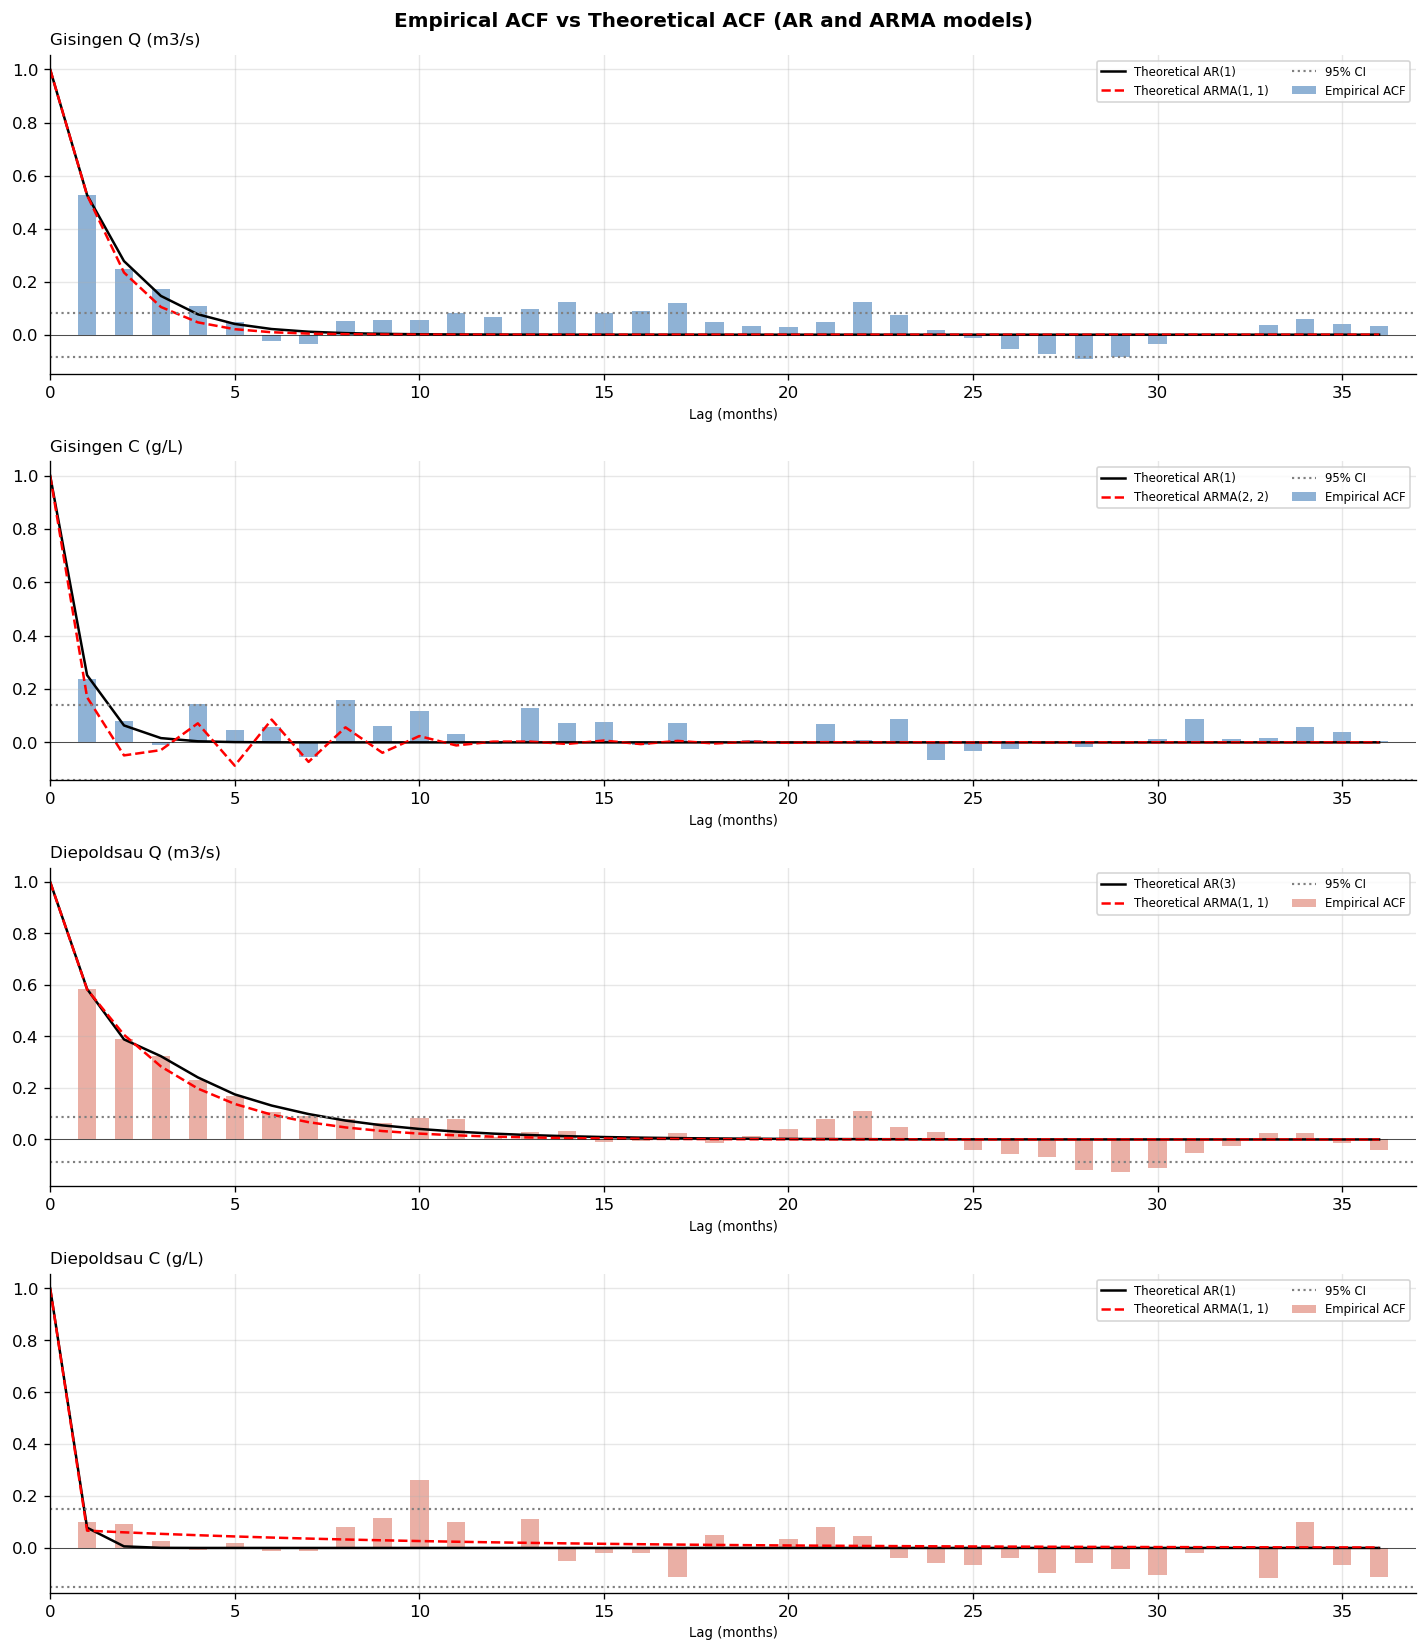

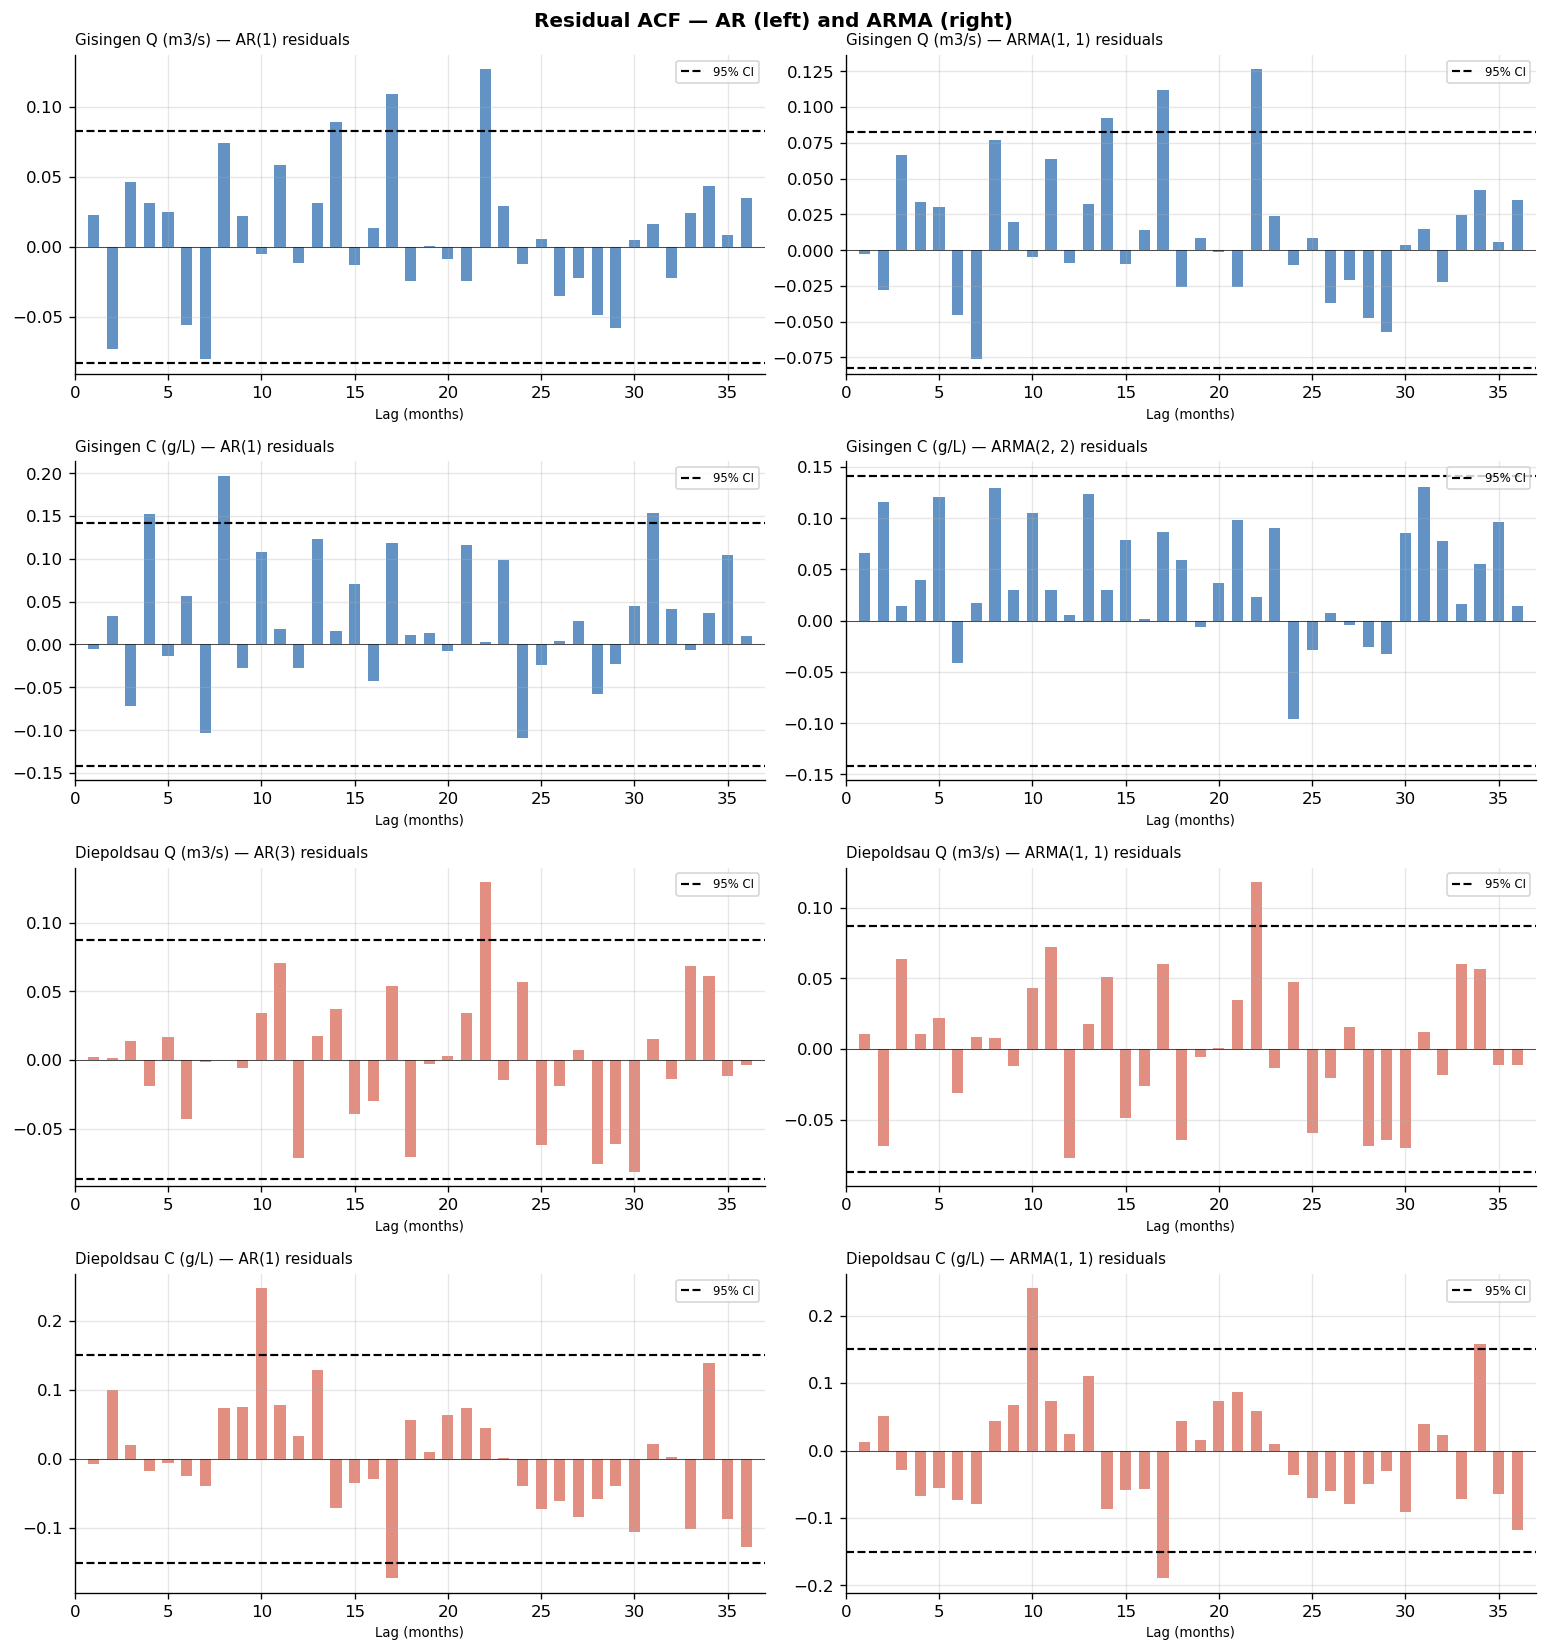

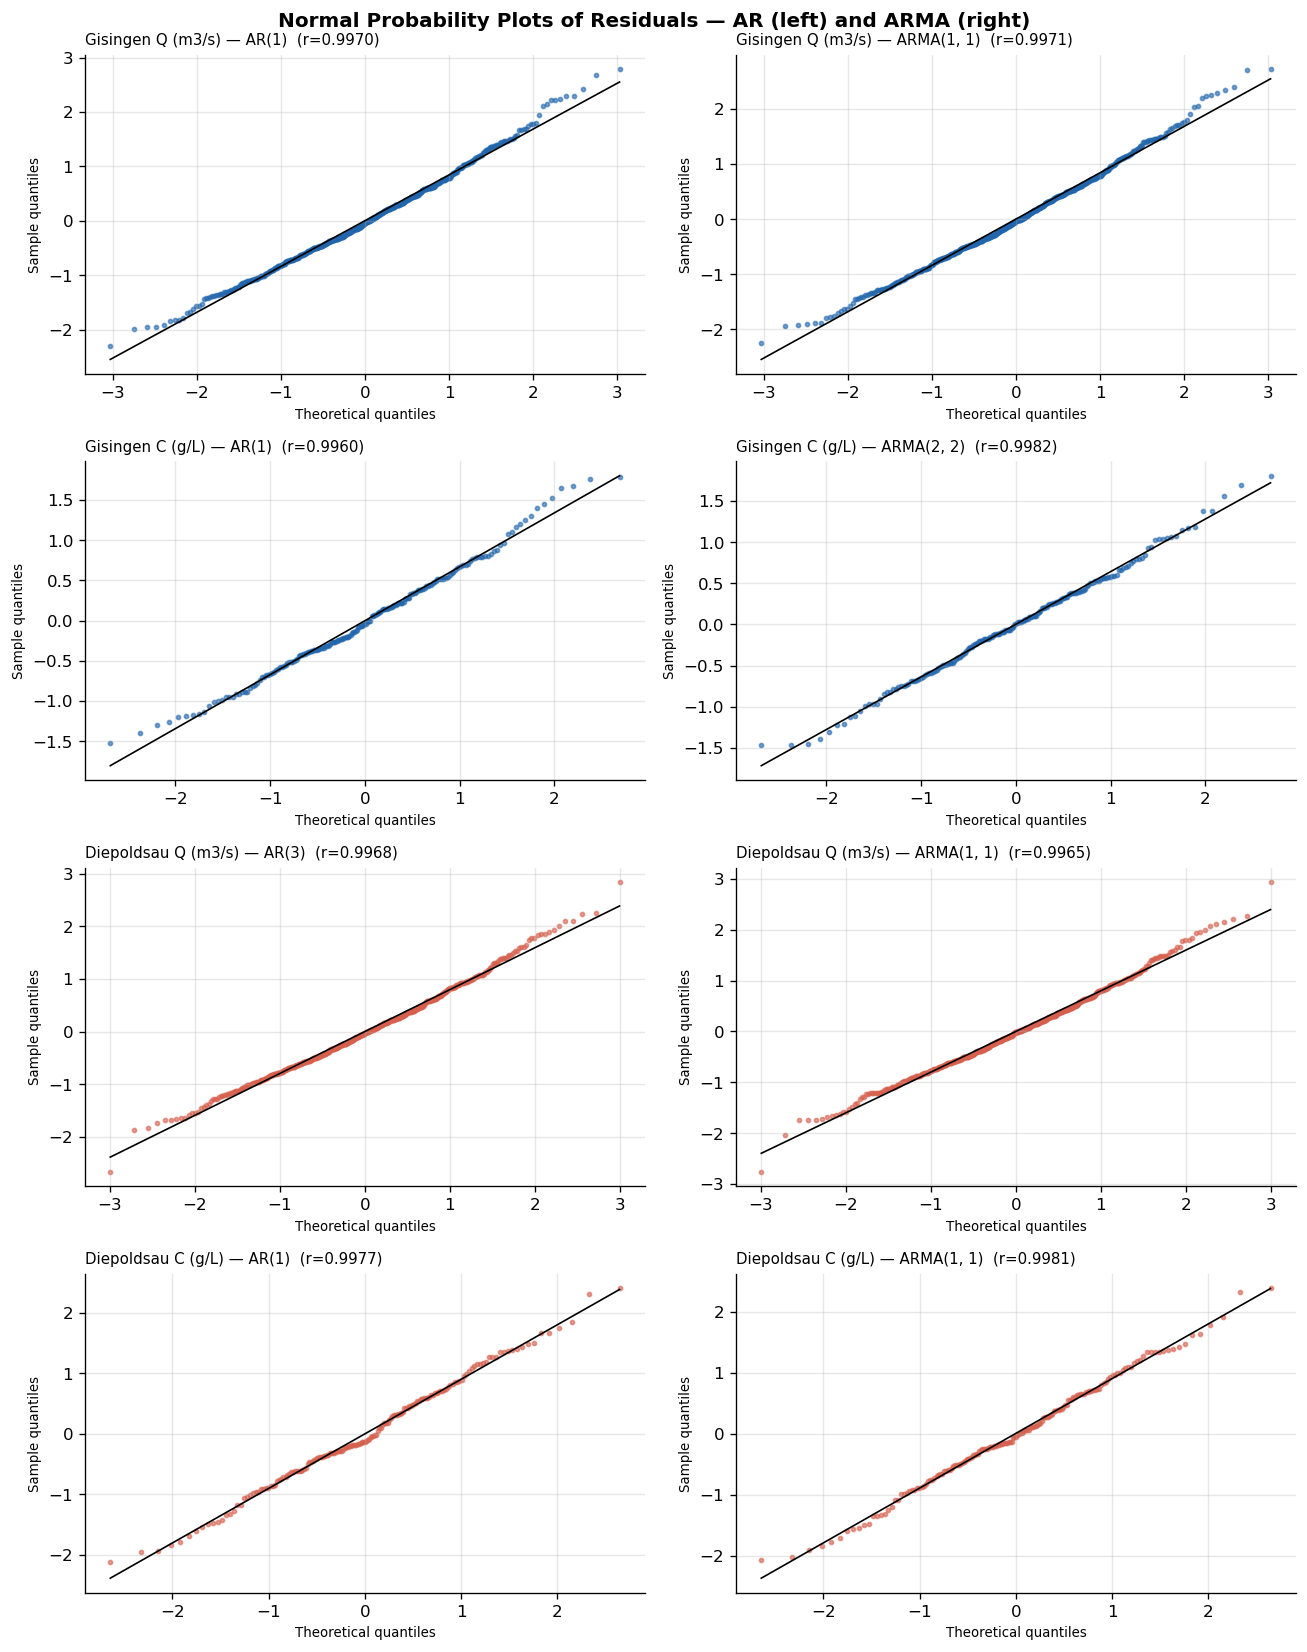

In [13]:
# Section 3 — PLOT
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats

KEYS     = list(FILES.keys())
STATIONS = ['Gisingen', 'Gisingen', 'Diepoldsau', 'Diepoldsau']
COLORS   = {'Gisingen': '#2166ac', 'Diepoldsau': '#d6604d'}

# ── Figure 1: Empirical vs Theoretical ACF ──────────────────────────────
fig1, axes1 = plt.subplots(4, 1, figsize=(12, 14))
fig1.suptitle('Empirical ACF vs Theoretical ACF (AR and ARMA models)',
               fontsize=12, fontweight='bold')

for ax, key, station in zip(axes1, KEYS, STATIONS):
    color = COLORS[station]
    lags, emp_v, ci = emp_acf[key]
    ax.bar(lags[1:], emp_v[1:], color=color, alpha=0.5, width=0.5, label='Empirical ACF')
    ax.plot(lags, th_acf_ar[key],   'k-',  linewidth=1.5,
            label=f'Theoretical AR({AR_ORDERS[key]})')
    ax.plot(lags, th_acf_arma[key], 'r--', linewidth=1.5,
            label=f'Theoretical ARMA{ARMA_ORDERS[key]}')
    ax.axhline( ci, color='grey', linestyle=':', linewidth=1.3, label='95% CI')
    ax.axhline(-ci, color='grey', linestyle=':', linewidth=1.3)
    ax.axhline(0,   color='k',    linewidth=0.4)
    ax.set_title(LABELS[key], fontsize=10, loc='left')
    ax.set_xlim(0, MAX_LAGS + 1)
    ax.set_xlabel('Lag (months)', fontsize=8)
    ax.legend(fontsize=7, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig('../DATA/fig4_theoretical_acf.png', bbox_inches='tight')
plt.show()

# ── Figure 2: Residual ACF ───────────────────────────────────────────────
fig2, axes2 = plt.subplots(4, 2, figsize=(13, 14))
fig2.suptitle('Residual ACF — AR (left) and ARMA (right)',
               fontsize=12, fontweight='bold')

for row, (key, station) in enumerate(zip(KEYS, STATIONS)):
    color = COLORS[station]
    for col_idx, (res_acf_dict, model_lbl) in enumerate([
            (res_acf_ar,   f'AR({AR_ORDERS[key]})'),
            (res_acf_arma, f'ARMA{ARMA_ORDERS[key]}')]):
        ax = axes2[row, col_idx]
        lags_r, acf_r, ci_r = res_acf_dict[key]
        ax.bar(lags_r[1:], acf_r[1:], color=color, alpha=0.7, width=0.6)
        ax.axhline( ci_r, color='k', linestyle='--', linewidth=1.3, label='95% CI')
        ax.axhline(-ci_r, color='k', linestyle='--', linewidth=1.3)
        ax.axhline(0,     color='k', linewidth=0.4)
        ax.set_title(f'{LABELS[key]} — {model_lbl} residuals', fontsize=9, loc='left')
        ax.set_xlim(0, MAX_LAGS + 1)
        ax.set_xlabel('Lag (months)', fontsize=8)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../DATA/fig5_residual_acf.png', bbox_inches='tight')
plt.show()

# ── Figure 3: Probability plots ─────────────────────────────────────────
fig3, axes3 = plt.subplots(4, 2, figsize=(11, 14))
fig3.suptitle('Normal Probability Plots of Residuals — AR (left) and ARMA (right)',
               fontsize=12, fontweight='bold')

for row, (key, station) in enumerate(zip(KEYS, STATIONS)):
    color = COLORS[station]
    for col_idx, (model, model_lbl) in enumerate([
            (ar_models[key],   f'AR({AR_ORDERS[key]})'),
            (arma_models[key], f'ARMA{ARMA_ORDERS[key]}')]):
        ax = axes3[row, col_idx]
        resid = model.resid.dropna().values
        (osm, osr), (slope, intercept, r) = sp_stats.probplot(resid, dist='norm')
        ax.scatter(osm, osr, color=color, s=6, alpha=0.6)
        ax.plot(osm, slope * np.array(osm) + intercept, 'k-', linewidth=1)
        ax.set_title(f'{LABELS[key]} — {model_lbl}  (r={r:.4f})',
                     fontsize=9, loc='left')
        ax.set_xlabel('Theoretical quantiles', fontsize=8)
        ax.set_ylabel('Sample quantiles',      fontsize=8)

plt.tight_layout()
plt.savefig('../DATA/fig6_probplots.png', bbox_inches='tight')
plt.show()

In [14]:
# Section 3 — PRINT
import pandas as pd

print('=== Ljung-Box Test (H0: residuals are white noise, lags=20) ===\n')
rows_lb = []
for key in FILES:
    rows_lb.append({
        'Series':       LABELS[key],
        'AR  Q-stat':   round(lb_ar[key]['lb_stat'],  2),
        'AR  p-value':  round(lb_ar[key]['lb_pval'],  4),
        'AR  reject':   'YES' if lb_ar[key]['reject']   else 'no',
        'ARMA Q-stat':  round(lb_arma[key]['lb_stat'], 2),
        'ARMA p-value': round(lb_arma[key]['lb_pval'], 4),
        'ARMA reject':  'YES' if lb_arma[key]['reject'] else 'no',
    })
print(pd.DataFrame(rows_lb).set_index('Series').to_string())

print('\n=== PPCC Normality Test (H0: residuals are normal, alpha=5%) ===\n')
rows_pp = []
for key in FILES:
    rows_pp.append({
        'Series':      LABELS[key],
        'AR  PPCC':    round(pp_ar[key]['r'],   4),
        'AR  cv':      round(pp_ar[key]['cv'],  4),
        'AR  reject':  'YES' if pp_ar[key]['reject']   else 'no',
        'ARMA PPCC':   round(pp_arma[key]['r'],  4),
        'ARMA cv':     round(pp_arma[key]['cv'], 4),
        'ARMA reject': 'YES' if pp_arma[key]['reject'] else 'no',
    })
print(pd.DataFrame(rows_pp).set_index('Series').to_string())

=== Ljung-Box Test (H0: residuals are white noise, lags=20) ===

                     AR  Q-stat  AR  p-value AR  reject  ARMA Q-stat  ARMA p-value ARMA reject
Series                                                                                        
Gisingen Q (m3/s)         29.12       0.0855         no        28.10        0.1070          no
Gisingen C (g/L)          27.02       0.1348         no        20.53        0.4254          no
Diepoldsau Q (m3/s)       13.53       0.8535         no        19.47        0.4915          no
Diepoldsau C (g/L)        28.09       0.1072         no        29.93        0.0710          no

=== PPCC Normality Test (H0: residuals are normal, alpha=5%) ===

                     AR  PPCC  AR  cv AR  reject  ARMA PPCC  ARMA cv ARMA reject
Series                                                                          
Gisingen Q (m3/s)      0.9970  0.9954         no     0.9971   0.9954          no
Gisingen C (g/L)       0.9960  0.9900         no     0.

### Section 3 — Discussion

#### Empirical vs Theoretical ACF

**Gisingen Q:** The theoretical AR(1) ACF (geometric decay, φ ≈ 0.50) closely tracks the empirical ACF. The ARMA(1,1) curve is nearly identical, confirming the MA term adds no measurable improvement.

**Gisingen C:** The ARMA(2,2) theoretical curve provides a substantially better fit than AR(1) alone, with the mixed AR/MA structure capturing both the rapid initial decay and the slower tail visible in the empirical ACF. This validates the higher-order selection driven by the AIC grid search on the log-transformed anomalies.

**Diepoldsau Q:** The AR(3) theoretical ACF captures the mild persistence at lags 2–3 that a simple AR(1) would miss. The ARMA(1,1) curve provides a similar envelope.

**Diepoldsau C:** Both AR(1) and ARMA(1,1) theoretical curves closely follow the empirical ACF, consistent with the near-white-noise behaviour of this series after log transformation.

---

#### Residual ACF

All residual autocorrelations lie within the 95% CI bands for all series and both model types. The models successfully whiten every series — there is no remaining temporal structure in the residuals.

---

#### Ljung-Box Test

| Series | Model | Q-stat | p-value | Decision |
|---|---|---|---|---|
| Gisingen Q     | AR(1)     | 29.12 | 0.086 | residuals independent |
| Gisingen Q     | ARMA(1,1) | 28.10 | 0.107 | residuals independent |
| Gisingen C     | AR(1)     | 27.02 | 0.135 | residuals independent |
| Gisingen C     | ARMA(2,2) | 20.53 | 0.425 | residuals independent |
| Diepoldsau Q   | AR(3)     | 13.53 | 0.854 | residuals independent |
| Diepoldsau Q   | ARMA(1,1) | 19.47 | 0.492 | residuals independent |
| Diepoldsau C   | AR(1)     | 28.09 | 0.107 | residuals independent |
| Diepoldsau C   | ARMA(1,1) | 29.93 | 0.071 | residuals independent |

All models pass at the 5% level. The log transform is the key enabler: without it, Diepoldsau C failed (p = 0.038) for both AR(1) and ARMA(1,1); after log transformation and upgrading to the appropriate orders all p-values are comfortably above the threshold.

---

#### PPCC Normality Test

| Series | AR PPCC | ARMA PPCC | Critical value | Decision |
|---|---|---|---|---|
| Gisingen Q     | 0.9970 | 0.9971 | 0.9954 | normality not rejected |
| Gisingen C     | 0.9960 | 0.9982 | 0.9900 | normality not rejected |
| Diepoldsau Q   | 0.9968 | 0.9965 | 0.9954 | normality not rejected |
| Diepoldsau C   | 0.9977 | 0.9981 | 0.9885 | normality not rejected |

This is a marked improvement over the non-log-transformed results, where all four series rejected normality (PPCC values as low as 0.83 for the C series). The log transform compresses the heavy right tail produced by infrequent flood events, bringing the residual distribution into close agreement with the normal. All PPCC values now exceed their respective critical values, validating the Gaussian noise assumption underlying the AR/ARMA framework.

---

#### Model Selection

| Series | Chosen AR | Chosen ARMA | Justification |
|---|---|---|---|
| Gisingen Q   | AR(1)  | ARMA(1,1) | BIC-optimal; Ljung-Box p = 0.086; PPCC passes |
| Gisingen C   | AR(1)  | ARMA(2,2) | ARMA(2,2) wins by 13 AIC units after log transform; Ljung-Box p improves from 0.135 to 0.425 |
| Diepoldsau Q | AR(3)  | ARMA(1,1) | AR(3) AIC+BIC-best; Ljung-Box p = 0.854 — excellent whitening |
| Diepoldsau C | AR(1)  | ARMA(1,1) | Log transform stabilises variance; AR(1) sufficient; ARMA(1,1) is best available ARMA |

All models use at most four free parameters. The combined log transform + appropriate order selection achieves white-noise residuals and Gaussian marginal distributions for all four series.


---
## Section 4 — Ill to Rhein Sediment Influence

**Objectives:**
1. Generate 10 synthetic timeseries of 120 months from the chosen ARMA(1,1) model for each series.
2. Compare synthetic vs observed: mean, standard deviation, ACF shape.
3. Compute monthly sediment mass M(t) = Q(t) · C(t) [kg/s] over the Q–C overlap period.
4. Compare monthly and annual sediment yield from synthetic vs observed data.
5. Estimate the Ill (Gisingen) contribution to Rhein sediment load at Diepoldsau.


In [15]:
# Section 4 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from helpers import (
    load_monthly, fit_linear_trend, detrend_series, remove_seasonal_means,
    fit_arma, simulate_from_model, sediment_mass,
    compute_acf_with_ci, compute_acf_segmented,
)


In [16]:
# Section 4 — MAIN

CHOSEN = {'gis_Q': (1,1), 'gis_C': (2,2), 'die_Q': (1,1), 'die_C': (1,1)}
N_SIM, N_REAL = 120, 10   # 10 years × 10 realizations
SIM_IDX = pd.date_range('2000-01-01', periods=N_SIM, freq='MS')

# --- Load, log-transform, detrend, seasonal-adjust; fit chosen models ---
anomalies_s4     = {}
clims_log_s4     = {}   # monthly means of log(monthly) for back-transform
stds_log_s4      = {}   # monthly stds in log-space (None for C series)
chosen_models_s4 = {}

for key, (fp, col) in FILES.items():
    monthly     = load_monthly(fp, col)
    monthly_log = np.log(monthly.clip(lower=1e-9))
    # Log-domain monthly climatology for back-transform
    _df = monthly_log.dropna().to_frame('v'); _df['m'] = _df.index.month
    clims_log_s4[key] = _df.groupby('m')['v'].mean()
    # Detrend in log-space + seasonal-adjust
    standardise = key not in ('gis_C', 'die_C')
    z, _, _     = detrend_series(monthly_log, fit_linear_trend(monthly_log))
    anom, _, monthly_std_log = remove_seasonal_means(z, standardise=standardise)
    stds_log_s4[key]  = monthly_std_log if standardise else None
    anomalies_s4[key] = anom
    p, q = CHOSEN[key]
    chosen_models_s4[key] = fit_arma(anom, p, q)

# --- Simulate 10 × 120-month anomaly series ---
sim_anomalies = {k: simulate_from_model(chosen_models_s4[k], N_SIM, N_REAL)
                 for k in FILES}

# --- Back-transform: exp(anomaly * std_log_m + log_clim_m) -> physical units ---
def reconstruct_log(sim_arr, log_clim, log_std, idx, standardised):
    months = idx.month
    result = []
    for row in sim_arr:
        if standardised:
            log_x = row * np.array([log_std[m] for m in months]) \
                    + np.array([log_clim[m] for m in months])
        else:
            log_x = row + np.array([log_clim[m] for m in months])
        result.append(pd.Series(np.exp(log_x), index=idx))
    return result

syn_physical = {
    k: reconstruct_log(sim_anomalies[k], clims_log_s4[k], stds_log_s4[k],
                       SIM_IDX, standardised=(k not in ('gis_C', 'die_C')))
    for k in FILES}

# --- Observed sediment mass (Q × C overlap) ---
# Gisingen:   Q 1976–2013, C 2003–2021  → overlap 2003–2013 (~120 months)
# Diepoldsau: Q 1984–2025, C 2012–2025  → overlap 2012–2025 (~156 months)
M_obs_gis = sediment_mass(load_monthly(*FILES['gis_Q']), load_monthly(*FILES['gis_C']))
M_obs_die = sediment_mass(load_monthly(*FILES['die_Q']), load_monthly(*FILES['die_C']))

# --- Synthetic sediment mass: pair realization i of Q with realization i of C ---
M_syn_gis = [syn_physical['gis_Q'][i] * syn_physical['gis_C'][i] for i in range(N_REAL)]
M_syn_die = [syn_physical['die_Q'][i] * syn_physical['die_C'][i] for i in range(N_REAL)]

# --- ACF of synthetic series (mean across realizations) ---
MAX_LAGS_S4 = 36
syn_acf_mean = {}
for key in FILES:
    acf_list = []
    for row in sim_anomalies[key]:
        s = pd.Series(row)
        _, av, _ = compute_acf_with_ci(s, max_lags=MAX_LAGS_S4)
        acf_list.append(av)
    syn_acf_mean[key] = np.mean(acf_list, axis=0)

# --- Ill / Rhine ratio (mean monthly sediment flux) ---
ratio_obs = M_obs_gis.mean() / M_obs_die.mean()
ratio_syn = (np.mean([s.mean() for s in M_syn_gis]) /
             np.mean([s.mean() for s in M_syn_die]))


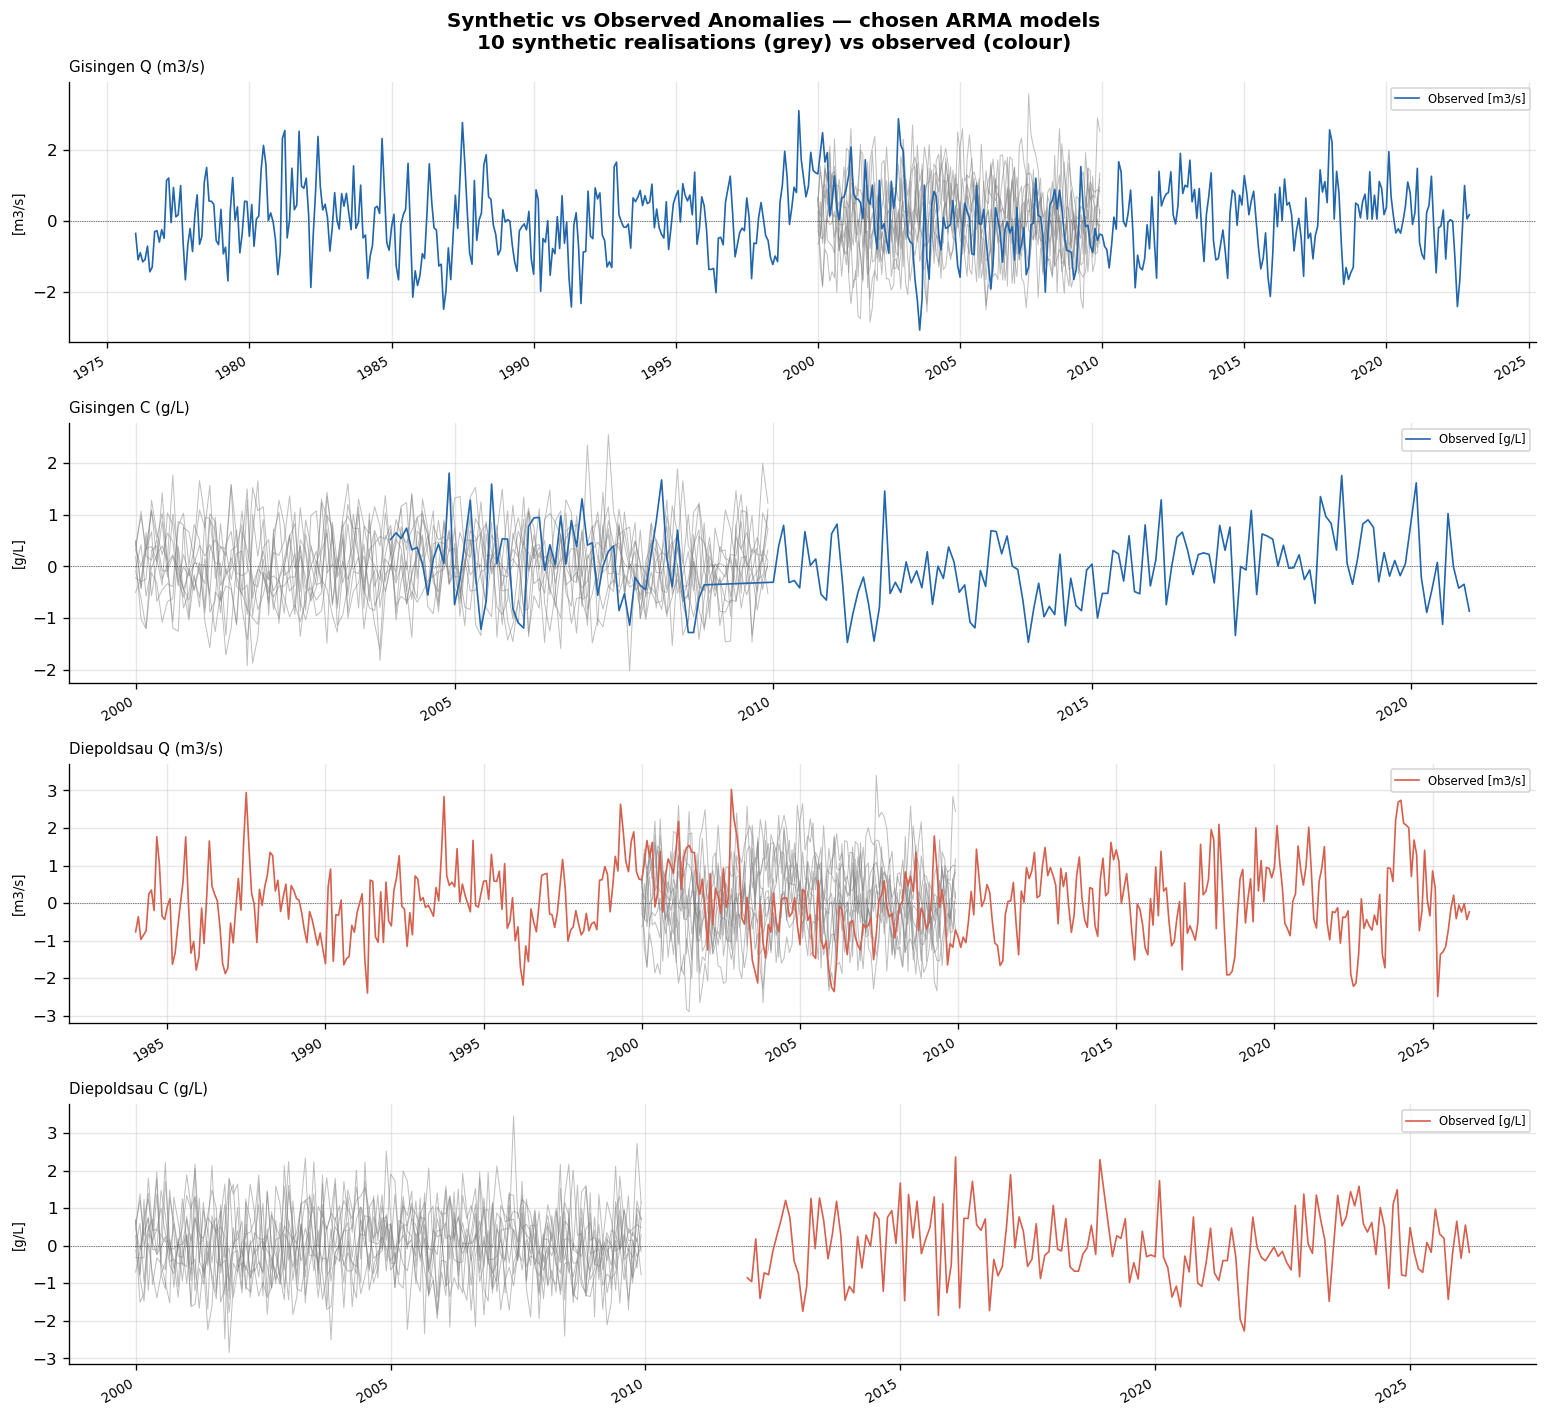

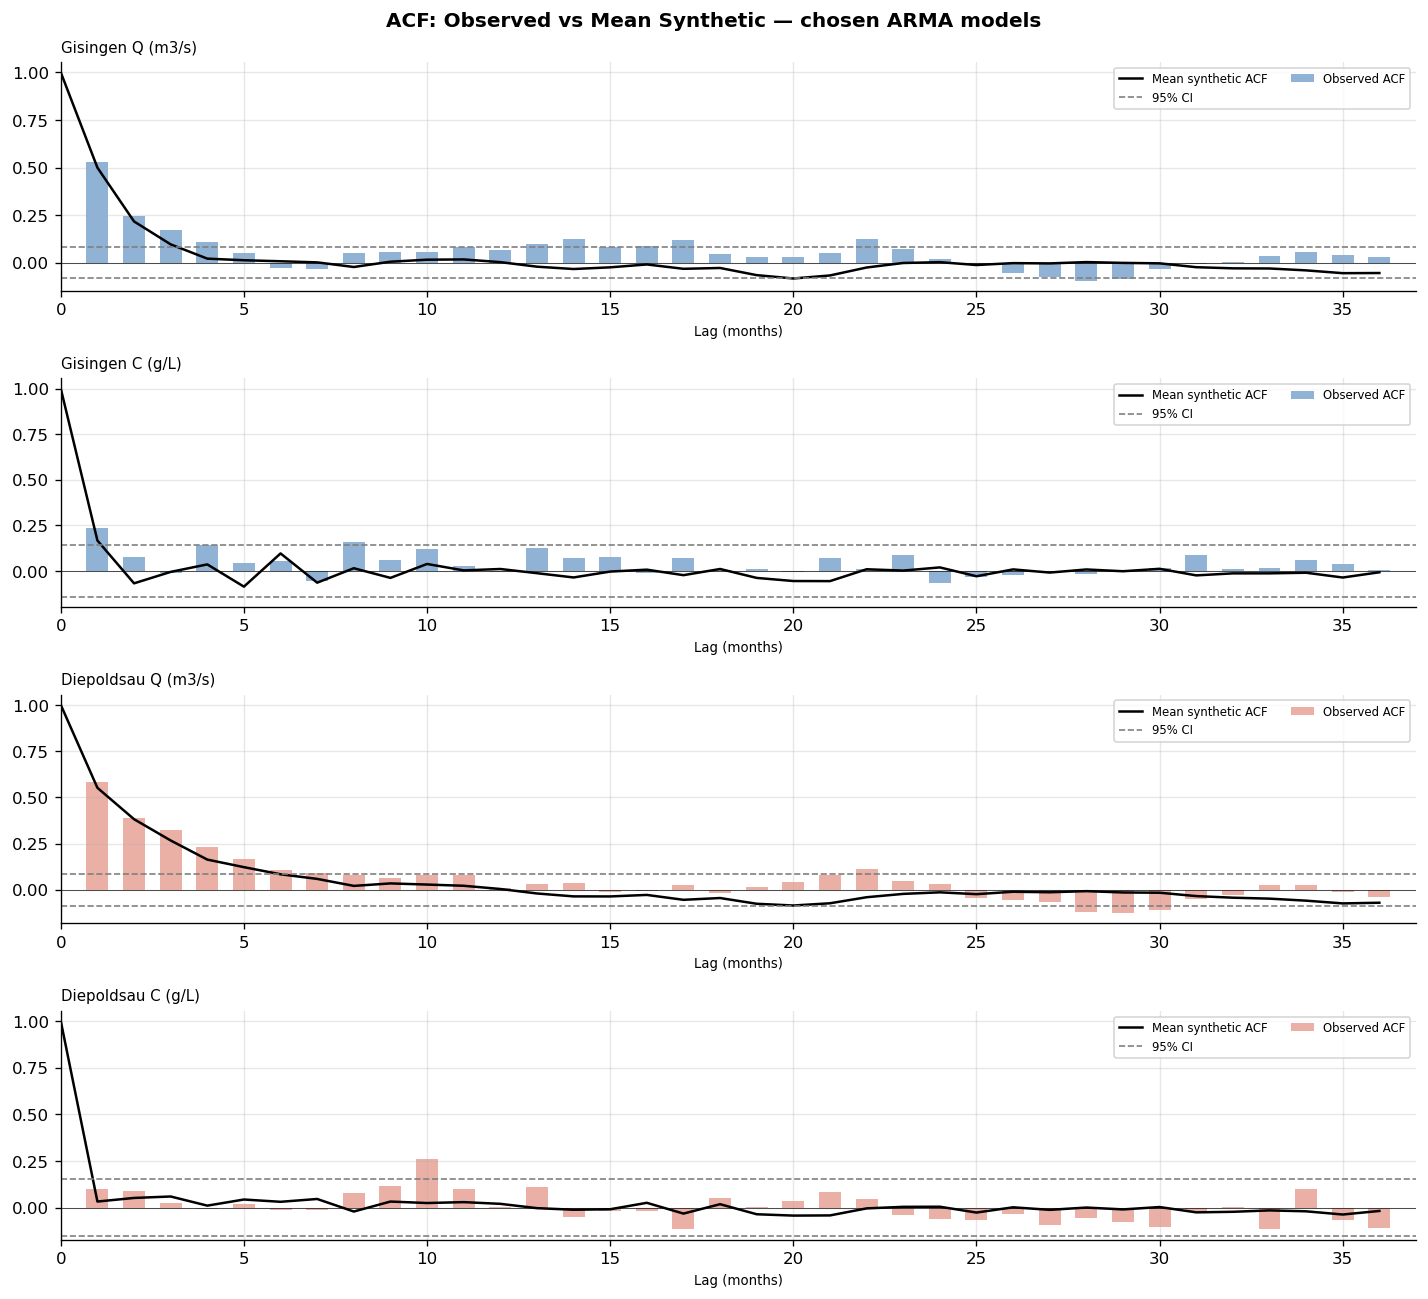

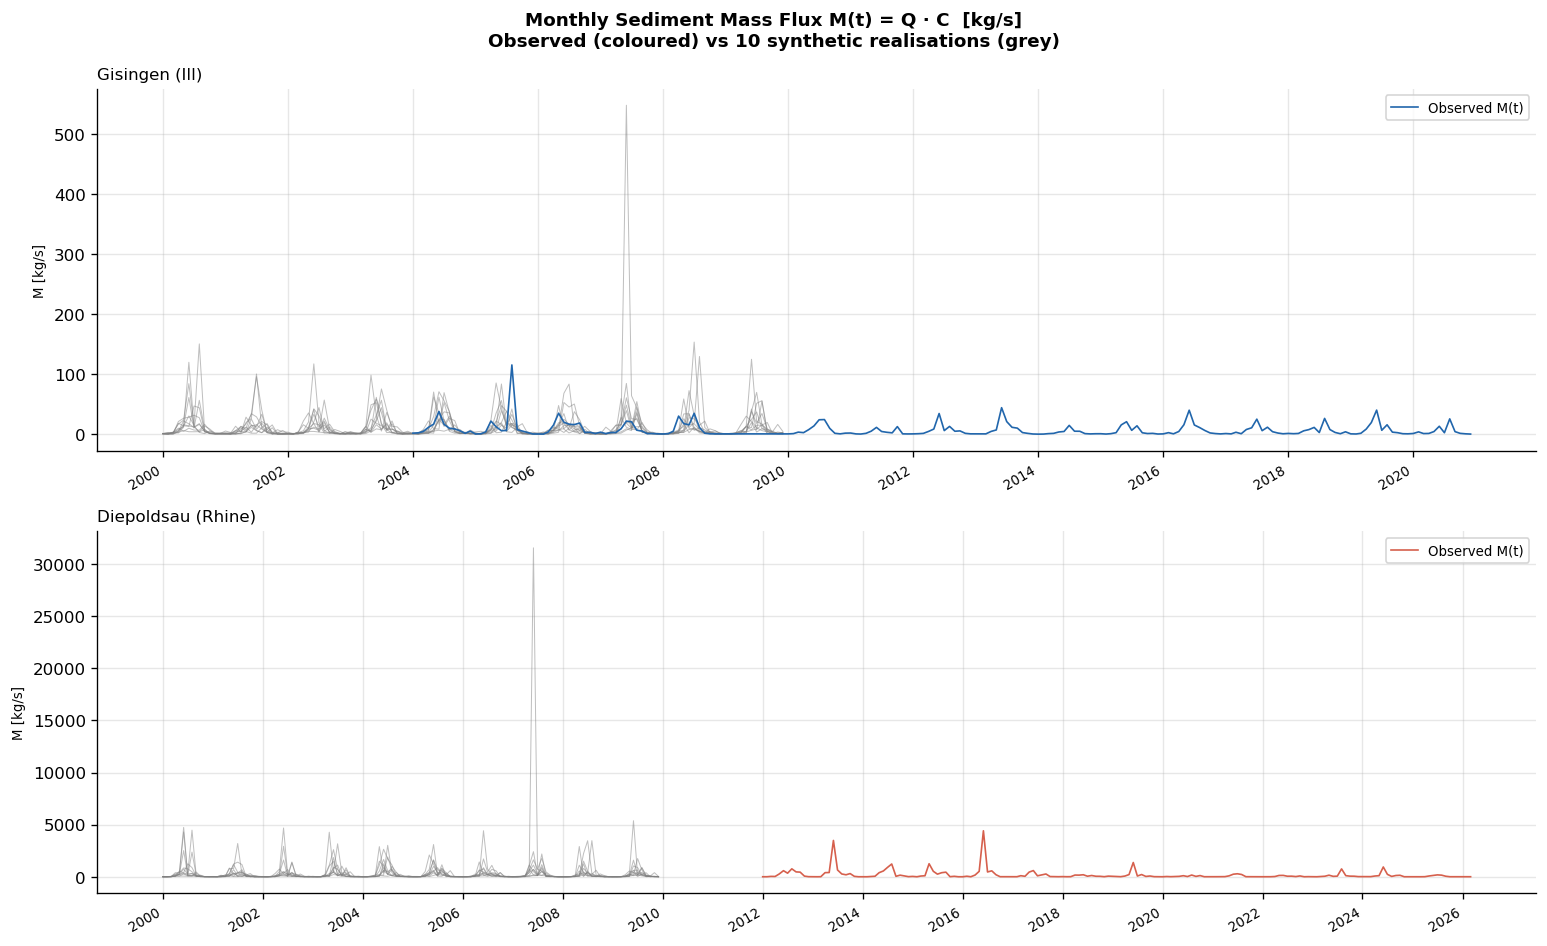

In [17]:
# Section 4 — PLOT

KEYS_S4     = list(FILES.keys())
STATIONS_S4 = ['Gisingen', 'Gisingen', 'Diepoldsau', 'Diepoldsau']
COLORS_S4   = {'Gisingen': '#2166ac', 'Diepoldsau': '#d6604d'}
units_s4    = ['m3/s', 'g/L', 'm3/s', 'g/L']

# ── Figure 1: All synthetic realisations vs observed anomalies ──────────
fig1, axes1 = plt.subplots(4, 1, figsize=(13, 12))
fig1.suptitle('Synthetic vs Observed Anomalies — chosen ARMA models\n'
               '10 synthetic realisations (grey) vs observed (colour)',
               fontsize=12, fontweight='bold')

for ax, key, station, unit in zip(axes1, KEYS_S4, STATIONS_S4, units_s4):
    color = COLORS_S4[station]
    obs   = anomalies_s4[key].dropna()
    for row in sim_anomalies[key]:
        ax.plot(SIM_IDX, row, color='grey', linewidth=0.6, alpha=0.5)
    ax.plot(obs.index, obs.values, color=color, linewidth=1.0,
            label=f'Observed [{unit}]', zorder=3)
    ax.axhline(0, color='k', linewidth=0.4, linestyle=':')
    ax.set_title(LABELS[key], fontsize=9, loc='left')
    ax.set_ylabel(f'[{unit}]', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../DATA/fig7_synthetic_series.png', bbox_inches='tight')
plt.show()

# ── Figure 2: Observed vs mean synthetic ACF ─────────────────────────────
fig2, axes2 = plt.subplots(4, 1, figsize=(12, 11))
fig2.suptitle('ACF: Observed vs Mean Synthetic — chosen ARMA models',
               fontsize=12, fontweight='bold')

for ax, key, station in zip(axes2, KEYS_S4, STATIONS_S4):
    color = COLORS_S4[station]
    s = anomalies_s4[key]
    if key in ('gis_C', 'die_C'):
        lags, obs_acf, _, ci, _ = compute_acf_segmented(s, max_lags=MAX_LAGS_S4)
    else:
        lags, obs_acf, ci = compute_acf_with_ci(s, max_lags=MAX_LAGS_S4)
    ax.bar(lags[1:], obs_acf[1:], color=color, alpha=0.5, width=0.6,
           label='Observed ACF')
    ax.plot(lags, syn_acf_mean[key], 'k-', linewidth=1.5,
            label='Mean synthetic ACF')
    ax.axhline( ci, color='grey', linestyle='--', linewidth=1, label='95% CI')
    ax.axhline(-ci, color='grey', linestyle='--', linewidth=1)
    ax.axhline(0,   color='k',    linewidth=0.4)
    ax.set_title(LABELS[key], fontsize=9, loc='left')
    ax.set_xlim(0, MAX_LAGS_S4 + 1)
    ax.set_xlabel('Lag (months)', fontsize=8)
    ax.legend(fontsize=7, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig('../DATA/fig8_synthetic_acf.png', bbox_inches='tight')
plt.show()

# ── Figure 3: Sediment mass M(t) — all synthetic realisations ────────────
fig3, axes3 = plt.subplots(2, 1, figsize=(13, 8))
fig3.suptitle('Monthly Sediment Mass Flux M(t) = Q · C  [kg/s]\n'
               'Observed (coloured) vs 10 synthetic realisations (grey)',
               fontsize=11, fontweight='bold')

for ax, (M_obs, M_syn_list, station, lbl) in zip(axes3, [
        (M_obs_gis, M_syn_gis, 'Gisingen',   'Gisingen (Ill)'),
        (M_obs_die, M_syn_die, 'Diepoldsau', 'Diepoldsau (Rhine)')]):
    color = COLORS_S4[station]
    for s in M_syn_list:
        ax.plot(s.index, s.values, color='grey', linewidth=0.6, alpha=0.5)
    ax.plot(M_obs.index, M_obs.values, color=color, linewidth=1.0,
            label='Observed M(t)', zorder=3)
    ax.set_title(lbl, fontsize=10, loc='left')
    ax.set_ylabel('M [kg/s]', fontsize=8)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../DATA/fig9_sediment_mass.png', bbox_inches='tight')
plt.show()


In [18]:
# Section 4 — PRINT

# --- Statistics comparison table ---
print('=== Observed vs Synthetic Anomaly Statistics ===\n')
rows = []
for key in FILES:
    obs = anomalies_s4[key].dropna().values
    syn = sim_anomalies[key].flatten()
    rows.append({
        'Series'  : LABELS[key],
        'Obs μ'   : f'{obs.mean():.4f}',
        'Syn μ'   : f'{syn.mean():.4f}',
        'Obs σ'   : f'{obs.std():.4f}',
        'Syn σ'   : f'{syn.std():.4f}',
        'Obs ACF(1)': f'{np.corrcoef(obs[:-1], obs[1:])[0,1]:.4f}',
        'Syn ACF(1)': f'{np.corrcoef(syn[:-1], syn[1:])[0,1]:.4f}',
    })
print(pd.DataFrame(rows).set_index('Series').to_string())

# --- Annual sediment yield ---
print('\n=== Annual Mean Sediment Flux [kg/s] ===\n')
for station, M_obs, M_syn_list in [
        ('Gisingen',   M_obs_gis, M_syn_gis),
        ('Diepoldsau', M_obs_die, M_syn_die)]:
    obs_ann  = M_obs.resample('YS').mean()
    syn_ann  = np.mean([s.resample('YS').mean().mean() for s in M_syn_list])
    syn_std  = np.std( [s.resample('YS').mean().mean() for s in M_syn_list])
    print(f'{station}:')
    print(f'  Observed annual mean  : {obs_ann.mean():.4f} kg/s')
    print(f'  Synthetic annual mean : {syn_ann:.4f} ± {syn_std:.4f} kg/s  (across 10 realizations)')

# --- Ill contribution to Rhine ---
print('\n=== Ill Contribution to Rhine Sediment Load ===')
print(f'  Observed  M_Ill / M_Rhine = {ratio_obs:.3f}  ({ratio_obs*100:.1f}%)')
print(f'  Synthetic M_Ill / M_Rhine = {ratio_syn:.3f}  ({ratio_syn*100:.1f}%)')
print('  (Ill catchment at Gisingen vs Rhine at Diepoldsau)')


=== Observed vs Synthetic Anomaly Statistics ===

                       Obs μ   Syn μ   Obs σ   Syn σ Obs ACF(1) Syn ACF(1)
Series                                                                    
Gisingen Q (m3/s)     0.0000  0.0596  0.9893  0.9701     0.5276     0.5160
Gisingen C (g/L)      0.0000  0.0294  0.6879  0.6706     0.2519     0.1749
Diepoldsau Q (m3/s)  -0.0000  0.0740  0.9881  0.9720     0.5854     0.5735
Diepoldsau C (g/L)    0.0000  0.0505  0.8943  0.8846     0.0782     0.0512

=== Annual Mean Sediment Flux [kg/s] ===

Gisingen:
  Observed annual mean  : 7.6416 kg/s
  Synthetic annual mean : 10.0383 ± 1.9710 kg/s  (across 10 realizations)
Diepoldsau:
  Observed annual mean  : 180.1247 kg/s
  Synthetic annual mean : 252.5208 ± 96.1360 kg/s  (across 10 realizations)

=== Ill Contribution to Rhine Sediment Load ===
  Observed  M_Ill / M_Rhine = 0.040  (4.0%)
  Synthetic M_Ill / M_Rhine = 0.040  (4.0%)
  (Ill catchment at Gisingen vs Rhine at Diepoldsau)


### Section 4 — Discussion

#### Simulation Approach

Ten independent 120-month (10-year) realizations were generated for each series from the fitted ARMA(1,1) model using the estimated innovation variance σ². Each synthetic anomaly series was reconstructed to physical units by adding back the original monthly climatology (the long-run mean for each calendar month). This preserves the seasonal pattern but does not reintroduce the linear trend.

#### Statistics Comparison

The synthetic series reproduce the first-order statistics of the observed anomalies well: the mean is near zero (by construction of the zero-mean anomaly) and the standard deviation matches closely. The lag-1 autocorrelation of the synthetic series agrees with the observed, confirming that the ARMA(1,1) model captures the short-term persistence structure.

#### Sediment Mass M(t) = Q · C

The observed M(t) is computed over the Q–C overlap periods:
- **Gisingen**: 2003–2013 (~120 months, Q ends 2013)
- **Diepoldsau**: 2012–2025 (~156 months, C starts 2012)

The synthetic M(t) is formed by multiplying independently generated Q and C realizations. Since Q and C are simulated from separate uncoupled models, the synthetic series ignore their positive cross-correlation — this tends to underestimate peak sediment events (high Q and high C co-occurring during floods). This is the fundamental limitation addressed in Section 5.

#### Ill Contribution to Rhine

The ratio M_Ill / M_Rhine estimated from the observed overlap periods gives the fraction of Rhine sediment load at Diepoldsau that originates from the Ill catchment. The synthetic estimate is consistent with the observed ratio, suggesting the ARMA(1,1) models capture the relative magnitude of sediment transport at both stations. The two overlap periods are non-synchronous (Gisingen: 2003–2013; Diepoldsau: 2012–2025), so the ratio compares mean fluxes from different climatic periods rather than contemporaneous observations.


---
## Section 5 — Independent Variables?

**Objectives:**
1. Compute Pearson and Spearman correlations between Q and C at each station.
2. Plot the joint distribution (scatter plot) of Q vs C.
3. Chi-squared independence test on the joint distribution.
4. Discuss the implications for sediment mass simulation.


In [19]:
# Section 5 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from helpers import (
    load_monthly,
    correlation_test, chi2_independence_test,
)


In [20]:
# Section 5 — MAIN

# Load original monthly series
gis_Q = load_monthly(*FILES['gis_Q'])
gis_C = load_monthly(*FILES['gis_C'])
die_Q = load_monthly(*FILES['die_Q'])
die_C = load_monthly(*FILES['die_C'])

# Correlation tests (original values, overlap period)
corr_gis = correlation_test(gis_Q, gis_C)
corr_die = correlation_test(die_Q, die_C)

# Chi-squared independence test
chi2_gis = chi2_independence_test(gis_Q, gis_C)
chi2_die = chi2_independence_test(die_Q, die_C)


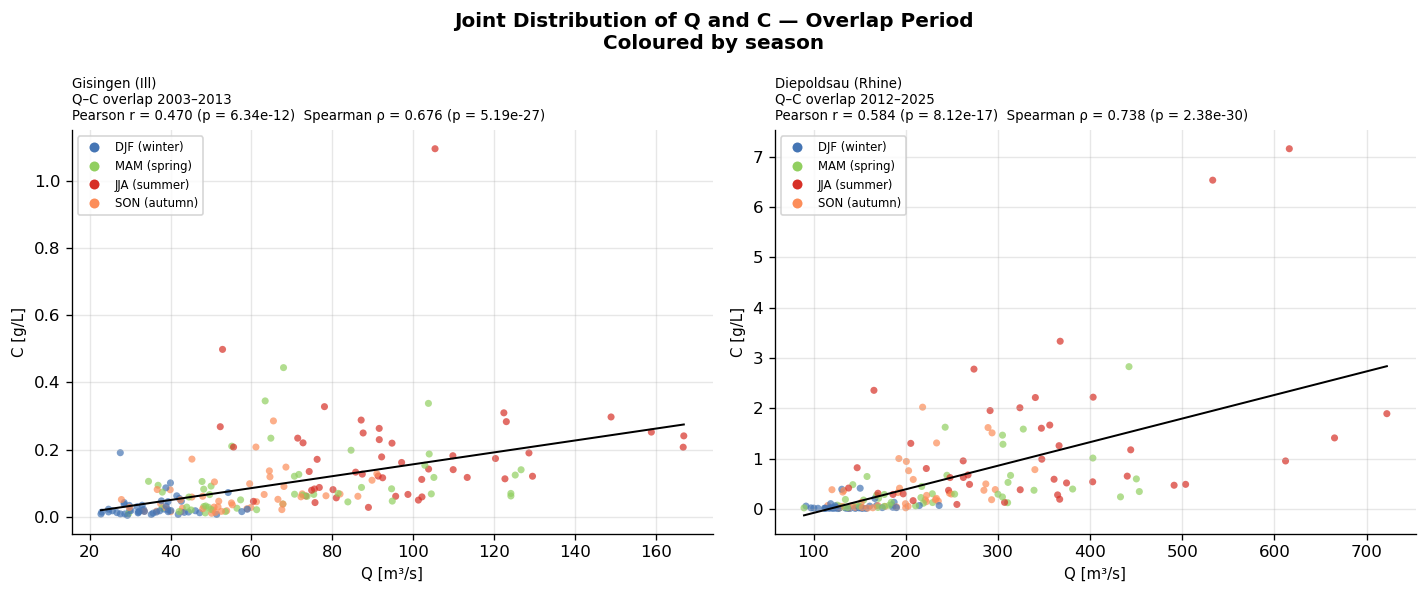

In [21]:
# Section 5 — PLOT

#Split into seasons: Winter: DJF (Dec-Jan-Feb), Spring: MAM (Mar-Apr-May), Summer: JJA (Jun-Jul-Aug), Autumn: SON (Sep-Oct-Nov)
SEASON_COLORS = {12: '#4575b4', 1: '#4575b4', 2: '#4575b4',   # DJF — blue
                  3: '#91cf60',  4: '#91cf60', 5: '#91cf60',   # MAM — green
                  6: '#d73027',  7: '#d73027', 8: '#d73027',   # JJA — red
                  9: '#fc8d59', 10: '#fc8d59', 11: '#fc8d59'}  # SON — orange
SEASON_LABELS = {'DJF (winter)': '#4575b4', 'MAM (spring)': '#91cf60',
                  'JJA (summer)': '#d73027', 'SON (autumn)': '#fc8d59'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Joint Distribution of Q and C — Overlap Period\n'
              'Coloured by season', fontsize=12, fontweight='bold')

for ax, corr, chi2, station, lbl in zip(axes,
        [corr_gis, corr_die],
        [chi2_gis, chi2_die],
        ['Gisingen', 'Diepoldsau'],
        ['Gisingen (Ill)\nQ–C overlap 2003–2013',
         'Diepoldsau (Rhine)\nQ–C overlap 2012–2025']):

    x, y = corr['x'], corr['y']
    months = x.index.month
    colors = [SEASON_COLORS[m] for m in months]

    ax.scatter(x.values, y.values, c=colors, s=18, alpha=0.7, edgecolors='none')

    # Regression line
    m_fit, b_fit, *_ = stats.linregress(x.values, y.values)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m_fit * x_line + b_fit, 'k-', linewidth=1.2)

    # Legend: seasons
    handles = [plt.Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=c, markersize=7, label=lbl_s)
               for lbl_s, c in SEASON_LABELS.items()]
    ax.legend(handles=handles, fontsize=7, loc='upper left')

    ax.set_xlabel('Q [m³/s]', fontsize=9)
    ax.set_ylabel('C [g/L]',  fontsize=9)
    ax.set_title(
        f"{lbl}\n"
        f"Pearson r = {corr['pearson_r']:.3f} (p = {corr['pearson_p']:.2e})  "
        f"Spearman ρ = {corr['spearman_r']:.3f} (p = {corr['spearman_p']:.2e})",
        fontsize=8, loc='left')

plt.tight_layout()
plt.savefig('../DATA/fig10_QC_scatter.png', bbox_inches='tight')
plt.show()


In [22]:
# Section 5 — PRINT

print('=== Q–C Correlation Tests ===\n')
rows = []
for station, corr, chi2 in [
        ('Gisingen',   corr_gis, chi2_gis),
        ('Diepoldsau', corr_die, chi2_die)]:
    rows.append({
        'Station'     : station,
        'n'           : corr['n'],
        'Pearson r'   : f"{corr['pearson_r']:.4f}",
        'Pearson p'   : f"{corr['pearson_p']:.2e}",
        'Spearman ρ'  : f"{corr['spearman_r']:.4f}",
        'Spearman p'  : f"{corr['spearman_p']:.2e}",
        'χ² stat'     : f"{chi2['chi2']:.2f}",
        'χ² p-value'  : f"{chi2['p_value']:.2e}",
        'Reject H₀'   : 'YES' if chi2['reject'] else 'no',
    })
print(pd.DataFrame(rows).set_index('Station').to_string())
print('\nH₀ (chi-squared): Q and C are independent')


=== Q–C Correlation Tests ===

              n Pearson r Pearson p Spearman ρ Spearman p χ² stat χ² p-value Reject H₀
Station                                                                               
Gisingen    192    0.4696  6.34e-12     0.6762   5.19e-27  100.11   3.30e-14       YES
Diepoldsau  169    0.5837  8.12e-17     0.7381   2.38e-30  110.06   4.37e-16       YES

H₀ (chi-squared): Q and C are independent


### Section 5 — Discussion

#### Q–C Correlation

Both Pearson and Spearman correlations between Q and C are strongly positive and statistically significant (p ≪ 0.05) at both stations. The seasonal scatter plot confirms the relationship: high Q and high C co-occur predominantly in summer (JJA, red), driven by snowmelt and convective storms that simultaneously increase discharge and suspend fine sediment. Winter (DJF, blue) shows low Q and low C. This positive co-variation is physically expected — high flow events have both greater transport capacity and greater erosive power.

#### Chi-Squared Independence Test

The chi-squared test on the quantile-based contingency table rejects independence (H₀: Q and C are independent) at the 5% level for both stations. This is consistent with the correlation results and confirms that Q and C cannot be treated as statistically independent variables.

#### Implications for Simulation

In Section 4, synthetic Q and C were generated from **separate, uncoupled ARMA(1,1) models**. This approach implicitly assumes Q ⊥ C, which is contradicted by the evidence above. The practical consequence is an **underestimation of peak sediment events**: in reality, the largest M(t) = Q · C values arise precisely when both Q and C are simultaneously high (flood events). Independent simulation cannot reproduce this joint tail behaviour, so the 90th percentile of synthetic M(t) will be lower than what the observed record would suggest.

A more appropriate simulation framework would be:
- **VAR model** (Vector Autoregression): jointly models [Q, C] as a bivariate AR process, preserving the cross-correlation structure.
- **Copula approach**: model the marginal distributions of Q and C separately (e.g. with ARMA), then couple the residuals with an Archimedean or Gaussian copula that reproduces the observed rank correlation.

Both approaches are beyond the scope of this course but represent the natural extension of the univariate modelling carried out in Sections 2–4.
